# COMPARISON OF MOCAP VS CAMERA , MOCAP VS ENCODER , CAMERA VS ENCODER 

In [1]:
# Cell 1
import importlib.util
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R
import cv2
import os
from scipy.interpolate import interp1d
import matplotlib.pyplot as pltnn 
import toml
import matplotlib.gridspec as gridspec
from math import sqrt
import warnings
from pathlib import Path
from scipy.signal import correlate
warnings.filterwarnings('ignore')
print('Libraries loaded OK')

Libraries loaded OK


## Step 1: Load Multiple Rigid body file

In [2]:
# Cell 2
try:
    # ── locate notebook & repo root ───────────────────────────────────────────
    try:
        _nb_file = Path(globals()['__vsc_ipynb_file__']).resolve()
        _nb_dir  = _nb_file.parent
    except KeyError:
        _nb_dir = Path.cwd()

    repo_root = _nb_dir
    for candidate in [_nb_dir, *_nb_dir.parents]:
        if (candidate / 'vaideesh').exists() or (candidate / '.venv').exists():
            repo_root = candidate
            break

    print(f'Repo root : {repo_root}')

    # ── load multiple_rigid_body module ───────────────────────────────────────
    _script_path = repo_root / 'vaideesh' / 'Analysis' / 'multiple_rigid_body.py'
    assert _script_path.exists(), f'Script not found: {_script_path}'

    _script_dir = str(_script_path.parent)
    if _script_dir not in sys.path:
        sys.path.insert(0, _script_dir)

    spec = importlib.util.spec_from_file_location('multiple_rigid_body', _script_path)
    mrb  = importlib.util.module_from_spec(spec)
    sys.modules['multiple_rigid_body'] = mrb
    spec.loader.exec_module(mrb)

    # ── bring helper functions into notebook namespace ────────────────────────
    add_datetime_col_3rb   = mrb.add_datetime_col_3rb
    trunkate_3_dfs         = mrb.trunkate_3_dfs
    trunkate_dfs           = mrb.trunkate_dfs
    get_rb_pos_cols        = mrb.get_rb_pos_cols
    get_rb_rot_cols        = mrb.get_rb_rot_cols
    get_rb_marker_name_3rb = mrb.get_rb_marker_name_3rb

    # ════════════════════════════════════════════════════════════════════════
    # load_csv_auto
    # ════════════════════════════════════════════════════════════════════════
    def load_csv_auto(csv_path, mrb, truncate=True):
        csv_path = str(csv_path)

        _raw      = pd.read_csv(csv_path, skiprows=2, header=None, dtype=str)
        _type_row = _raw.iloc[0].fillna('').str.strip().tolist()
        _name_row = _raw.iloc[1].fillna('').str.strip().tolist()

        detected = []
        for t, name in zip(_type_row, _name_row):          # ← fixed: n → name
            if t == 'Rigid Body' and name and name not in detected:
                detected.append(name)

        n_bodies = len(detected)                            # ← fixed: n → n_bodies
        print(f'  Detected {n_bodies} rigid bod{"y" if n_bodies == 1 else "ies"}: {detected}')

        if n_bodies not in (2, 3):
            raise ValueError(
                f'load_csv_auto: found {n_bodies} rigid bodies {detected} in\n  {csv_path}\n'
                f'read_3_rigid_body_csv supports 2 or 3 bodies only.'
            )

        rb_dfs, st_time = mrb.read_3_rigid_body_csv(csv_path, rb_names=detected)
        rb_dfs = mrb.add_datetime_col_3rb(rb_dfs, st_time)

        if truncate:
            names = list(rb_dfs.keys())
            if n_bodies == 3:
                rb_dfs[names[0]], rb_dfs[names[1]], rb_dfs[names[2]] = mrb.trunkate_3_dfs(
                    rb_dfs[names[0]], rb_dfs[names[1]], rb_dfs[names[2]],
                    display_print=True,
                )
            else:
                rb_dfs[names[0]], rb_dfs[names[1]] = mrb.trunkate_dfs(
                    rb_dfs[names[0]], rb_dfs[names[1]],
                    display_print=True,
                )

        return rb_dfs, st_time, detected

    # ── File paths ────────────────────────────────────────────────────────────
    TABLE_FILE = mrb.FILE
    NOARK_FILE = "E:\\Ragav\\MS Bio Engineering\\NOARK_backbone\\mocap_recordings\\mocap_recordings_may_15\\rotation_t1_may_15.csv"

    print(f'Loading TABLE file (geometry only): {TABLE_FILE}')
    table_rb_dfs, table_st_time, table_bodies = load_csv_auto(TABLE_FILE, mrb)

    for required in ('tframe', 'table'):
        if required not in table_rb_dfs:                   # ← fixed: assert → if/raise
            raise ValueError(
                f'"{required}" not found in TABLE file. '
                f'Detected bodies: {table_bodies}'
            )

    print(f'\nLoading NOARK file (experiment data): {NOARK_FILE}')
    noark_rb_dfs, noark_st_time, noark_bodies = load_csv_auto(NOARK_FILE, mrb)

    # ── Merge ─────────────────────────────────────────────────────────────────
    rb_dfs = {
        'tframe': table_rb_dfs['tframe'],
        'table' : table_rb_dfs['table'],
    }
    for k, v in noark_rb_dfs.items():
        if k not in ('tframe', 'table'):
            rb_dfs[k] = v

    print(f'\nCombined rb_dfs keys : {list(rb_dfs.keys())}')
    print(f'Script loaded        : {_script_path}')
    print(f'TABLE st_time (geometry only) : {table_st_time}')
    print(f'NOARK st_time (time alignment): {noark_st_time}')

    # ── Final sanity checks ───────────────────────────────────────────────────
    if 'tframe' not in rb_dfs:
        raise ValueError(f"Missing 'tframe'. Keys: {list(rb_dfs.keys())}")
    if 'table' not in rb_dfs:
        raise ValueError(f"Missing 'table'. Keys: {list(rb_dfs.keys())}")
    if len(rb_dfs) < 3:
        raise ValueError(f"Expected ≥3 bodies after merge, got: {list(rb_dfs.keys())}")

    noark_key = [k for k in rb_dfs if k not in ('tframe', 'table')][0]
    print("\n✅ Cell 2 passed all checks")
    print(f"   rb_dfs keys : {list(rb_dfs.keys())}")
    print(f"   noark rows  : {rb_dfs[noark_key].shape[0]}")

except FileNotFoundError as e:
    print(f"❌ File not found: {e}")
except ValueError as e:
    print(f"❌ Value error: {e}")
except KeyError as e:
    print(f"❌ Missing key: {e}")
except Exception as e:
    print(f"❌ Unexpected error: {type(e).__name__}: {e}")
    raise

Repo root : E:\Ragav\MS Bio Engineering\NOARK_backbone
Loading TABLE file (geometry only): E:\Ragav\MS Bio Engineering\NOARK_backbone\mocap_recordings\mocap_recordings_may_15\table_frame_may_15.csv
  Detected 2 rigid bodies: ['table', 'tframe']
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 1312

Loading NOARK file (experiment data): E:\Ragav\MS Bio Engineering\NOARK_backbone\mocap_recordings\mocap_recordings_may_15\rotation_t1_may_15.csv
  Detected 2 rigid bodies: ['table', 'noark']
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 25315

Combined rb_dfs keys : ['tframe', 'table', 'noark']
Script loaded        : E:\Ragav\MS Bio Engineering\NOARK_backbone\vaideesh\Analysis\multiple_rigid_body.py
TABLE st_time (geometry only) : 2026-05-15 17:24:15.111000
NOARK st_time (time alignment): 2026-05-15 17:12:04.138000

✅ Cell 2 passed all checks
   rb_dfs keys : ['tframe', 'table', 'noark']
   noark rows  : 25316


## Verify Data frames

In [3]:
# Cell 3
print('DataFrames from multiple_rigid_body.py:')
print(f'{"Body":<10}  {"Shape":<15}  {"Has time col"}')
print('-' * 40)
for name, df in rb_dfs.items():
    has_time = 'time' in df.columns
    print(f'{name:<10}  {str(df.shape):<15}  {has_time}')

print('\nNaN rows per body:')
for name, df in rb_dfs.items():
    nan_rows = df.isna().any(axis=1).sum()
    print(f'  {name}: {nan_rows} NaN rows out of {len(df)}')

DataFrames from multiple_rigid_body.py:
Body        Shape            Has time col
----------------------------------------
tframe      (1313, 23)       True
table       (1313, 35)       True
noark       (25316, 27)      True

NaN rows per body:
  tframe: 1 NaN rows out of 1313
  table: 1 NaN rows out of 1313
  noark: 1 NaN rows out of 25316


## Inspect RAW DATAFRAMES

In [4]:
# # Cell 4
# # Tframe is the most critical since it defines the coordinate system, so we check it first.
# print('── tframe ──')
# display(rb_dfs['tframe'].head(3))

In [5]:
# # Cell 5
# # NOARK body is next most critical since it contains the data we want to compare against, so we check it next.
# noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
# print(f'── {noark_key} ──')
# display(rb_dfs[noark_key].head(3))

In [6]:
# # Cell 6
# #TABLE body is least critical since it's only used for time alignment, so we check it last. 
# print('── table ──')
# display(rb_dfs['table'].head(30))

## Cell 5 — Define `transform_to_tframe()`

**Coordinate frame construction (per frame, from mocap marker positions):**

| Step | Detail |
|---|---|
| Origin | `tframe_marker_1` position in mocap frame |
| X axis | `tframe_marker_2 − origin`, normalised |
| Y axis | `tframe_marker_4 − origin`, Gram-Schmidt orthogonalised then normalised |
| Z axis | `X × Y` (right-handed) |
| Translation reference | `tframe_marker_1` → becomes **(0, 0, 0)** in table frame |

**Transform formula:** `p_table = R_mocap2table.T @ (p_mocap − t_mocap)`  
where `R_mocap2table` columns are `[vxnorm, vynorm, vznorm]` and `t_mocap = tvec(tframe_marker_3)`.

**Units:** Motive exports positions in **metres** — no conversion needed.  
**Column suffix `_m`** makes the unit explicit in every position column.

In [7]:
# # Cell 7
# # ── RECORDING-SPECIFIC CONFIG ─────────────────────────────────────────────────
# # Update these three lines for each new recording using your notes sheet.f
# #
# #   ORIGIN_MARKER : tframe marker that becomes (0,0,0)       → notes: tframe_marker_2
# #   X_MARKER      : tframe marker that defines the +X axis    → notes: tframe_marker_1
# #   Y_MARKER      : tframe marker that defines the +Y axis    → notes: tframe_marker_3
# #   NOARK_MARKER  : noark rigid-body marker index to track    → notes: noark_marker_1
# # ─────────────────────────────────────────────────────────────────────────────
# ORIGIN_MARKER = 1   # tframe_marker_2  (origin)
# X_MARKER      = 2   # tframe_marker_1  (defines +X direction)
# Y_MARKER      = 3   # tframe_marker_3  (defines +Y direction)
# NOARK_MARKER  = 2    # noark_marker_1   (the NOARK point to track)

# def transform_to_tframe(rb_dfs,
#                         origin_marker=ORIGIN_MARKER,
#                         x_marker=X_MARKER,
#                         y_marker=Y_MARKER,
#                         noark_marker=NOARK_MARKER):
#     tframe_df = rb_dfs['tframe'].copy()
#     noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
#     noark_df  = rb_dfs[noark_key].copy()
#     print(f'Using noark key: "{noark_key}"')
#     print(f'tframe: origin=m{origin_marker}, X=m{x_marker}-m{origin_marker}, Y=m{y_marker}-m{origin_marker}')
#     print(f'noark : tracking marker m{noark_marker}')
#     table_df  = rb_dfs['table'].copy()

#     def _mean_marker(df, label, m_idx):
#         cols = [f'{label}_marker_m{m_idx}_x',
#                 f'{label}_marker_m{m_idx}_y',
#                 f'{label}_marker_m{m_idx}_z']
#         return df[cols].mean().values.astype(float)

#     # ── Build a SINGLE fixed coordinate frame from mean tframe marker positions ──
#     org = _mean_marker(tframe_df, 'tframe', origin_marker)  # origin
#     px  = _mean_marker(tframe_df, 'tframe', x_marker)       # point along +X
#     py  = _mean_marker(tframe_df, 'tframe', y_marker)       # point along +Y

#     v1 = px - org   # raw X-axis vector
#     v2 = py - org   # raw Y-axis vector (not yet orthogonalised)

#     # Gram-Schmidt orthonormalisation
#     vxnorm = v1 / np.linalg.norm(v1)
#     vycap  = v2 - np.dot(v2, vxnorm) * vxnorm
#     vynorm = vycap / np.linalg.norm(vycap)
#     vznorm = np.cross(vxnorm, vynorm)   # BUG FIX: was cross(vynorm, vxnorm) → left-handed!

#     R_mat = np.stack([vxnorm, vynorm, vznorm], axis=-1)  # (3,3) — fixed
#     t_vec = org 
#     mocap_mark_offset = np.array([0,0,0.05]).reshape((3,1))
#     tvec_mocap = (R_mat @ mocap_mark_offset + np.array(t_vec).reshape((3,1))).T[0]                           # origin in mocap frame
#     # ── Helper: transform any (N,3) array into table frame ───────────────────
#     def pos_to_tframe(p_mocap):
#         return (R_mat.T @ (p_mocap - t_vec).T).T          # (N, 3)

#     # ── noark ─────────────────────────────────────────────────────────────────
#     noark_result = pd.DataFrame({
#         'frame'  : noark_df['frame'].values,
#         'seconds': noark_df['seconds'].values,
#         'time'   : noark_df['time'].values,
#     })

#     col_suffix = f'm{noark_marker}'
#     out_suffix = f'noark_m{noark_marker}'
#     try:
#         p = noark_df[[f'{noark_key}_marker_{col_suffix}_x',
#                       f'{noark_key}_marker_{col_suffix}_y',
#                       f'{noark_key}_marker_{col_suffix}_z']].values.astype(float)
#         p_tf = pos_to_tframe(p)
#         noark_result[f'{out_suffix}_tf_x_m'] = p_tf[:, 0]
#         noark_result[f'{out_suffix}_tf_y_m'] = p_tf[:, 1]
#         noark_result[f'{out_suffix}_tf_z_m'] = p_tf[:, 2]
#     except KeyError:
#         print(f'  ERROR: noark marker m{noark_marker} columns not found!')
#         print(f'  Available noark cols: {[c for c in noark_df.columns if "marker" in c]}')

#     # ── table ─────────────────────────────────────────────────────────────────
#     table_result = pd.DataFrame({
#         'frame'  : table_df['frame'].values,
#         'seconds': table_df['seconds'].values,
#         'time'   : table_df['time'].values,
#     })

#     for i in range(1, 7):
#         try:
#             p = table_df[[f'table_marker_m{i}_x',
#                            f'table_marker_m{i}_y',
#                            f'table_marker_m{i}_z']].values.astype(float)
#             p_tf = pos_to_tframe(p)
#             table_result[f'table_m{i}_tf_x_m'] = p_tf[:, 0]
#             table_result[f'table_m{i}_tf_y_m'] = p_tf[:, 1]
#             table_result[f'table_m{i}_tf_z_m'] = p_tf[:, 2]
#         except KeyError:
#             pass

#     return {
#         'noark_in_tframe' : noark_result.reset_index(drop=True),
#         'table_in_tframe' : table_result.reset_index(drop=True),
#         '_R_mat'          : R_mat,
#         '_t_vec'          : t_vec,
#         '_noark_marker'   : noark_marker,
#     }


In [8]:
# Cell 7 with XZ
# ── RECORDING-SPECIFIC CONFIG ─────────────────────────────────────────────────
ORIGIN_MARKER = 1   # tframe marker that becomes (0,0,0)
X_MARKER      = 2   # tframe marker that defines the +X axis
Z_MARKER      = 3   # tframe marker that defines the +Z axis
NOARK_MARKER  = 1   # noark marker to track

def transform_to_tframe(rb_dfs,
                        origin_marker=ORIGIN_MARKER,
                        x_marker=X_MARKER,
                        z_marker=Z_MARKER,
                        noark_marker=NOARK_MARKER):
    tframe_df = rb_dfs['tframe'].copy()
    noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
    noark_df  = rb_dfs[noark_key].copy()
    print(f'Using noark key: "{noark_key}"')
    print(f'tframe: origin=m{origin_marker}, X=m{x_marker}-m{origin_marker}, Z=m{z_marker}-m{origin_marker}')
    print(f'noark : tracking marker m{noark_marker}')
    table_df  = rb_dfs['table'].copy()

    def _mean_marker(df, label, m_idx):
        cols = [f'{label}_marker_m{m_idx}_x',
                f'{label}_marker_m{m_idx}_y',
                f'{label}_marker_m{m_idx}_z']
        return df[cols].mean().values.astype(float)

    # ── Build coordinate frame from mean tframe marker positions ─────────────
    org = _mean_marker(tframe_df, 'tframe', origin_marker)  # origin
    px  = _mean_marker(tframe_df, 'tframe', x_marker)       # point along +X
    pz  = _mean_marker(tframe_df, 'tframe', z_marker)       # point along +Z

    v1 = px - org   # raw X-axis vector
    v2 = pz - org   # raw Z-axis vector (not yet orthogonalised)

    # Gram-Schmidt orthonormalisation in XZ plane
    vxnorm = v1 / np.linalg.norm(v1)
    vzcap  = v2 - np.dot(v2, vxnorm) * vxnorm
    vznorm = -(vzcap / np.linalg.norm(vzcap))               # Bug fix: was 'vnorm', now 'vznorm'
    vynorm = np.cross(vznorm, vxnorm)                        # Bug fix: Y = Z × X (right-handed)

    R_mat = np.stack([vxnorm, vynorm, vznorm], axis=-1)      # Bug fix: was using undefined 'vynorm' before cross
    t_vec = org                                              # origin in mocap frame
    print(t_vec, "t_vec")
    # ── Helper: transform any (N,3) array into table frame ───────────────────
    def pos_to_tframe(p_mocap):
        return (R_mat.T @ (p_mocap - t_vec).T).T            # (N, 3)

    # ── noark ─────────────────────────────────────────────────────────────────
    noark_result = pd.DataFrame({
        'frame'  : noark_df['frame'].values,
        'seconds': noark_df['seconds'].values,
        'time'   : noark_df['time'].values,
    })

    col_suffix = f'm{noark_marker}'
    out_suffix = f'noark_m{noark_marker}'
    try:
        p = noark_df[[f'{noark_key}_marker_{col_suffix}_x',
                      f'{noark_key}_marker_{col_suffix}_y',
                      f'{noark_key}_marker_{col_suffix}_z']].values.astype(float)
        p_tf = pos_to_tframe(p)
        noark_result[f'{out_suffix}_tf_x_m'] = p_tf[:, 0]
        noark_result[f'{out_suffix}_tf_y_m'] = p_tf[:, 1]
        noark_result[f'{out_suffix}_tf_z_m'] = p_tf[:, 2]
    except KeyError:
        print(f'  ERROR: noark marker m{noark_marker} columns not found!')
        print(f'  Available noark cols: {[c for c in noark_df.columns if "marker" in c]}')

    # ── table ─────────────────────────────────────────────────────────────────
    table_result = pd.DataFrame({
        'frame'  : table_df['frame'].values,
        'seconds': table_df['seconds'].values,
        'time'   : table_df['time'].values,
    })

    for i in range(1, 7):
        try:
            p = table_df[[f'table_marker_m{i}_x',
                           f'table_marker_m{i}_y',
                           f'table_marker_m{i}_z']].values.astype(float)
            p_tf = pos_to_tframe(p)
            table_result[f'table_m{i}_tf_x_m'] = p_tf[:, 0]
            table_result[f'table_m{i}_tf_y_m'] = p_tf[:, 1]
            table_result[f'table_m{i}_tf_z_m'] = p_tf[:, 2]
        except KeyError:
            pass

    return {
        'noark_in_tframe' : noark_result.reset_index(drop=True),
        'table_in_tframe' : table_result.reset_index(drop=True),
        '_R_mat'          : R_mat,
        '_t_vec'          : t_vec,
        '_noark_marker'   : noark_marker,
    }

## RUN THE TRANSFORMATION

In [9]:
# Cell 8
tframe_dfs = transform_to_tframe(rb_dfs)

print('noark_in_tframe shape :', tframe_dfs['noark_in_tframe'].shape)
print('table_in_tframe shape :', tframe_dfs['table_in_tframe'].shape)
print('\nnoark_in_tframe columns:')
print(tframe_dfs['noark_in_tframe'].columns.tolist())
print('\ntable_in_tframe columns:')
print(tframe_dfs['table_in_tframe'].columns.tolist())

Using noark key: "noark"
tframe: origin=m1, X=m2-m1, Z=m3-m1
noark : tracking marker m1
[0.17658788 0.17937566 0.02865438] t_vec
noark_in_tframe shape : (25316, 6)
table_in_tframe shape : (1313, 21)

noark_in_tframe columns:
['frame', 'seconds', 'time', 'noark_m1_tf_x_m', 'noark_m1_tf_y_m', 'noark_m1_tf_z_m']

table_in_tframe columns:
['frame', 'seconds', 'time', 'table_m1_tf_x_m', 'table_m1_tf_y_m', 'table_m1_tf_z_m', 'table_m2_tf_x_m', 'table_m2_tf_y_m', 'table_m2_tf_z_m', 'table_m3_tf_x_m', 'table_m3_tf_y_m', 'table_m3_tf_z_m', 'table_m4_tf_x_m', 'table_m4_tf_y_m', 'table_m4_tf_z_m', 'table_m5_tf_x_m', 'table_m5_tf_y_m', 'table_m5_tf_z_m', 'table_m6_tf_x_m', 'table_m6_tf_y_m', 'table_m6_tf_z_m']


## INSPECT TRANSFORMED DATAFRAMES

In [10]:
# # Cell 9
# print('── noark in tframe ──')
# display(tframe_dfs['noark_in_tframe'].head())

In [11]:
# # Cell 10
# print('── table in tframe ──')
# display(tframe_dfs['table_in_tframe'].head())

## SANITY CHECKS

In [12]:
# Cell 11
# ── Sanity checks — fixed (3,3) rotation matrix ──────────────────────────────
R_mat = tframe_dfs['_R_mat']           # (3,3)
t_vec = tframe_dfs['_t_vec']           # (3,) — tframe_marker_2 = origin

def _chk(label, val, tol, unit=''):
    print(f'  {label:<46} {val:.2e} {unit}  →  {"PASS ✓" if val < tol else "FAIL ✗"}')

print('Sanity checks')
print('─' * 62)

# Check 1: origin (t_vec = m1) maps to (0,0,0)
p_origin = R_mat.T @ (t_vec - t_vec)
_chk('Check 1  origin  → (0,0,0)', np.max(np.abs(p_origin)), 1e-10, 'm')

# Check 2: R columns are unit vectors
col_norms = np.linalg.norm(R_mat, axis=0)
_chk('Check 2  R columns are unit vectors', np.max(np.abs(col_norms - 1.0)), 1e-6)

# Check 3: R.T @ R = I
RtR = R_mat.T @ R_mat
_chk('Check 3  R.T @ R = I  (orthogonality)', np.max(np.abs(RtR - np.eye(3))), 1e-6)

# Check 4: det(R) = +1
det = np.linalg.det(R_mat)
print(f'  {"Check 4  det(R) = +1  (right-handed)":<46} det = {det:.8f}  →  {"PASS ✓" if abs(det-1.0)<1e-6 else "FAIL ✗"}')

print(f'\nR_mat (columns = X/Y/Z axes of table frame in mocap):\n{np.round(R_mat, 6)}')
print(f'\nt_vec (table origin = tframe in mocap, m): {np.round(t_vec, 6)}')

Sanity checks
──────────────────────────────────────────────────────────────
  Check 1  origin  → (0,0,0)                     0.00e+00 m  →  PASS ✓
  Check 2  R columns are unit vectors            0.00e+00   →  PASS ✓
  Check 3  R.T @ R = I  (orthogonality)          2.22e-16   →  PASS ✓
  Check 4  det(R) = +1  (right-handed)           det = 1.00000000  →  PASS ✓

R_mat (columns = X/Y/Z axes of table frame in mocap):
[[ 7.66770e-02 -2.15820e-02 -9.96822e-01]
 [ 4.96000e-04  9.99766e-01 -2.16070e-02]
 [ 9.97056e-01  1.16200e-03  7.66690e-02]]

t_vec (table origin = tframe in mocap, m): [0.176588 0.179376 0.028654]


## NOARK POSITION IN TABLE FRAME 

In [13]:
# Cell 12 — noark marker position in table frame
_nm = tframe_dfs['_noark_marker']   # e.g. 1
df_n = tframe_dfs['noark_in_tframe']
print(f'noark Marker {_nm} — position in tframe coordinate system (metres)')
_xcol = f'noark_m{_nm}_tf_x_m'
_ycol = f'noark_m{_nm}_tf_y_m'
_zcol = f'noark_m{_nm}_tf_z_m'
print(df_n[['frame','seconds', _xcol, _ycol, _zcol]].to_string(index=False))
print('\nSummary statistics (metres):')
display(df_n[[_xcol, _ycol, _zcol]].describe().round(6))


noark Marker 1 — position in tframe coordinate system (metres)
 frame  seconds  noark_m1_tf_x_m  noark_m1_tf_y_m  noark_m1_tf_z_m
     0     0.00        -0.278007         0.012585        -0.115972
     1     0.01        -0.277997         0.012589        -0.115976
     2     0.02        -0.278005         0.012596        -0.115971
     3     0.03        -0.278007         0.012576        -0.115984
     4     0.04        -0.278015         0.012580        -0.115979
     5     0.05        -0.278188         0.012768        -0.115812
     6     0.06        -0.278005         0.012568        -0.116012
     7     0.07        -0.278029         0.012561        -0.116008
     8     0.08        -0.278019         0.012564        -0.116000
     9     0.09        -0.278022         0.012573        -0.115988
    10     0.10        -0.278007         0.012580        -0.116005
    11     0.11        -0.278003         0.012591        -0.115989
    12     0.12        -0.277883         0.012461        -0.116127

,noark_m1_tf_x_m,noark_m1_tf_y_m,noark_m1_tf_z_m
count,25315.000000,25315.000000,25315.000000
mean,-0.059083,0.009089,-0.303011
std,0.195598,0.002739,0.113726
min,-0.383267,0.003303,-0.512489
25%,-0.240958,0.006579,-0.413552
50%,-0.082365,0.009103,-0.295999
75%,0.104496,0.011499,-0.202690
max,0.363958,0.015203,-0.086259


## TABLE MARKER POSITION P1-P4 AND MOTOR POSITION M1 AND M2

In [14]:
# Cell 13
df_t = tframe_dfs['table_in_tframe']
for i in range(1, 7):
    cols = [f'table_m{i}_tf_x_m', f'table_m{i}_tf_y_m', f'table_m{i}_tf_z_m']
    # print(f'\ntable Marker {i} — position in tframe coordinate system (metres)')
    # print(df_t[['frame','seconds'] + cols].to_string(index=False))
    # print(f'\nSummary statistics — Marker {i} (metres):')
    # display(df_t[cols].describe().round(6))

## XY POSITION OF ALL TABLE MARKERS

In [15]:
# Cell 14
import numpy as np

df_t = tframe_dfs['table_in_tframe'].copy()

print('Mean positions of all table markers in table frame (cm)')
print(f'  {"Marker":<12}  {"X (cm)":>10}  {"Y (cm)":>10}  {"Z (cm)":>10}')
print('-' * 50)
marker_xy = {}
for mid in range(1, 7):
    xc = f'table_m{mid}_tf_x_m'
    yc = f'table_m{mid}_tf_y_m'
    zc = f'table_m{mid}_tf_z_m'
    if xc in df_t.columns:
        x = df_t[xc].mean() * 100
        y = df_t[yc].mean() * 100
        z = df_t[zc].mean() * 100
        marker_xy[mid] = (x, y)
        print(f'  table_m{mid:<6}    {x:>10.2f}  {y:>10.2f}  {z:>10.2f}')
    else:
        print(f'  table_m{mid:<6}    NOT FOUND')

Mean positions of all table markers in table frame (cm)
  Marker            X (cm)      Y (cm)      Z (cm)
--------------------------------------------------
  table_m1             -49.34      -11.30       -2.96
  table_m2             -49.55      -13.08      -77.32
  table_m3              49.08      -10.93       -3.04
  table_m4              49.05      -12.38      -77.44
  table_m5               6.47       -8.95      -69.99
  table_m6              -6.54       -8.78      -70.05


In [16]:
# # Raw mocap positions of table markers
# table_df = rb_dfs['table']

# print('Mean positions of all table markers in RAW MOCAP frame (m)')
# print(f'  {"Marker":<12}  {"X (m)":>10}  {"Y (m)":>10}  {"Z (m)":>10}')
# print('-' * 50)
# for i in range(1, 7):
#     xc = f'table_marker_m{i}_x'
#     yc = f'table_marker_m{i}_y'
#     zc = f'table_marker_m{i}_z'
#     if xc in table_df.columns:
#         x = table_df[xc].mean()
#         y = table_df[yc].mean()
#         z = table_df[zc].mean()
#         print(f'  table_m{i:<6}    {x:>10.4f}  {y:>10.4f}  {z:>10.4f}')
#     else:
#         print(f'  table_m{i:<6}    NOT FOUND')

## NOARK : X and Z Position Over Time

Plots X and Z position in the table coordinate frame over time.

- **Top subplot**: X position (left ↔ right) over time
- **Bottom subplot**: Z position (up ↕ down) over time
- Axes in **cm** for readability.

Plotting NOARK marker: m1


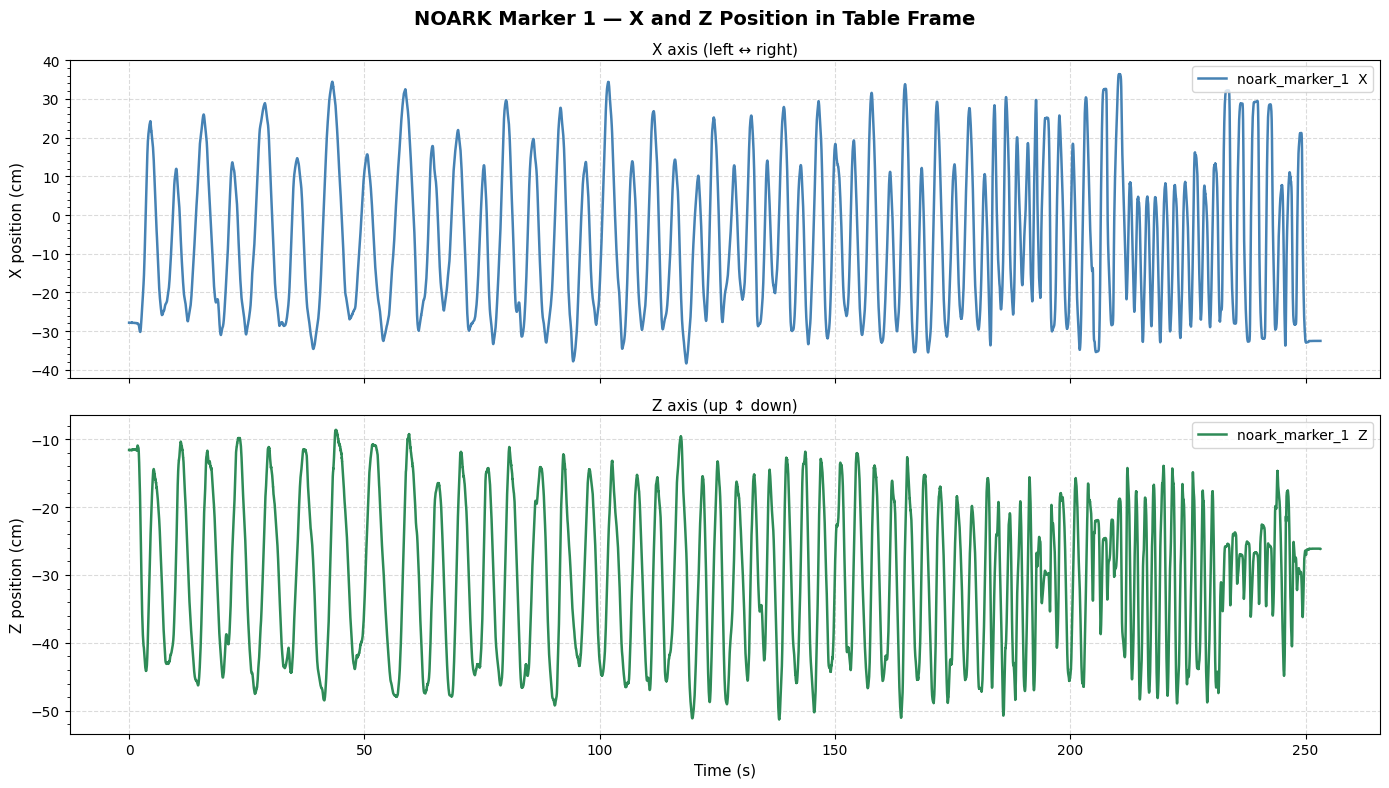

X range: nan → nan cm  (span nan cm)
Z range: nan → nan cm  (span nan cm)
Duration: 253.15 s  (25316 frames)


In [17]:
# Cell 15
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df_n = tframe_dfs['noark_in_tframe'].copy()
_nm  = tframe_dfs['_noark_marker']
PLOT_MARKER = f'm{_nm}'

assert f'noark_{PLOT_MARKER}_tf_x_m' in df_n.columns, (
    f'noark_{PLOT_MARKER}_tf_x_m not found. Available: {df_n.columns.tolist()}'
)
print(f'Plotting NOARK marker: {PLOT_MARKER}')

mocap_t = df_n['seconds'].values
mocap_x = df_n[f'noark_{PLOT_MARKER}_tf_x_m'].values * 100.0   # m → cm
mocap_z = df_n[f'noark_{PLOT_MARKER}_tf_z_m'].values * 100.0   # m → cm

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'NOARK Marker {_nm} — X and Z Position in Table Frame',
             fontsize=14, fontweight='bold')

# ── X subplot ─────────────────────────────────────────────────────────────────
ax1.plot(mocap_t, mocap_x, color='steelblue', lw=1.8, label=f'noark_marker_{_nm}  X')
ax1.set_ylabel('X position (cm)', fontsize=11)
ax1.set_title('X axis (left ↔ right)', fontsize=11, pad=4)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.45)
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.tick_params(axis='both', labelsize=10)

_xi = np.argmin(mocap_x); _xa = np.argmax(mocap_x)
ax1.annotate(f'min {mocap_x[_xi]:.1f} cm', xy=(mocap_t[_xi], mocap_x[_xi]),
             xytext=(0, -18), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='steelblue'),
             fontsize=8, color='steelblue', ha='center')
ax1.annotate(f'max {mocap_x[_xa]:.1f} cm', xy=(mocap_t[_xa], mocap_x[_xa]),
             xytext=(0, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='steelblue'),
             fontsize=8, color='steelblue', ha='center')

# ── Z subplot ─────────────────────────────────────────────────────────────────
ax2.plot(mocap_t, mocap_z, color='seagreen', lw=1.8, label=f'noark_marker_{_nm}  Z')  # BUG FIX: was 'marker_2'
ax2.set_ylabel('Z position (cm)', fontsize=11)
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_title('Z axis (up ↕ down)', fontsize=11, pad=4)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.45)
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.tick_params(axis='both', labelsize=10)

_zi = np.argmin(mocap_z); _za = np.argmax(mocap_z)
ax2.annotate(f'min {mocap_z[_zi]:.1f} cm', xy=(mocap_t[_zi], mocap_z[_zi]),
             xytext=(0, -18), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='seagreen'),
             fontsize=8, color='seagreen', ha='center')
ax2.annotate(f'max {mocap_z[_za]:.1f} cm', xy=(mocap_t[_za], mocap_z[_za]),
             xytext=(0, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='seagreen'),
             fontsize=8, color='seagreen', ha='center')

plt.tight_layout()
plt.savefig('Mocap_NOARK_position.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'X range: {mocap_x.min():.2f} → {mocap_x.max():.2f} cm  (span {mocap_x.max()-mocap_x.min():.2f} cm)')
print(f'Z range: {mocap_z.min():.2f} → {mocap_z.max():.2f} cm  (span {mocap_z.max()-mocap_z.min():.2f} cm)')
print(f'Duration: {mocap_t[-1] - mocap_t[0]:.2f} s  ({len(mocap_t)} frames)')


## 2D Trajectory of NOARK Marker 1 (X–Z Table Frame)

Scatter plot of X and Z position in the table coordinate frame.
- **Colour** encodes time progression (early → late).
- **▲ triangles** mark pulley reference points P1–P4 from table markers.
- Axes in **cm**.

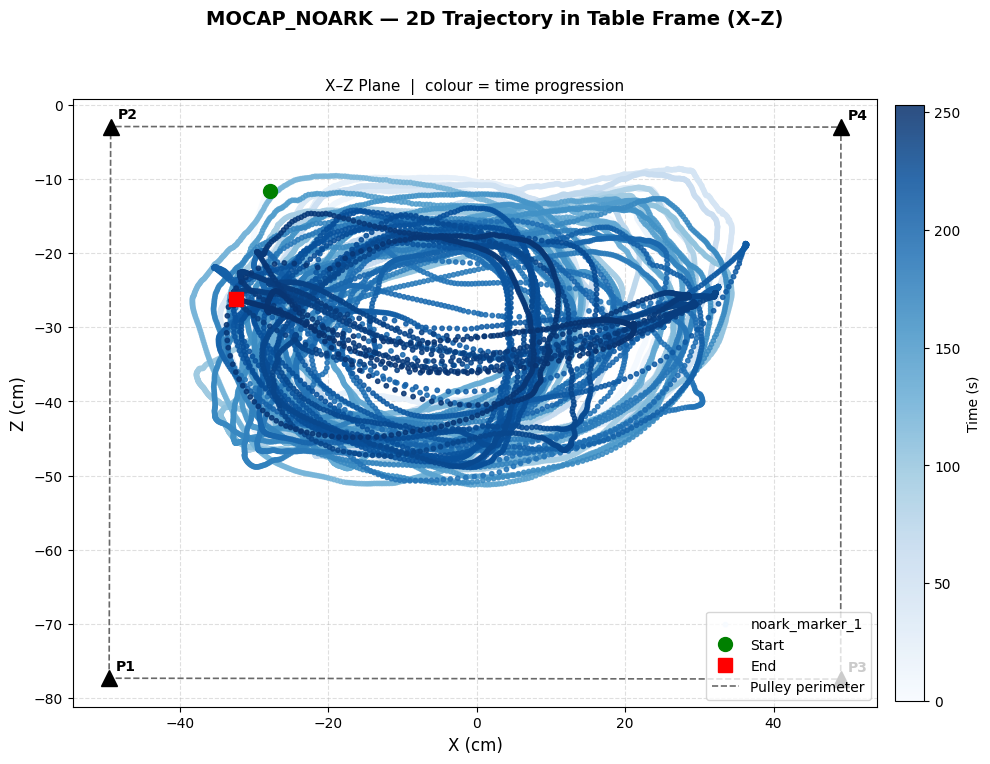

X range : nan → nan cm
Z range : nan → nan cm
Frames  : 25316  |  Duration: 253.15 s


In [18]:
# Cell 16
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df_n = tframe_dfs['noark_in_tframe'].copy()
df_t = tframe_dfs['table_in_tframe'].copy()
_nm  = tframe_dfs['_noark_marker']

t_sec    = df_n['seconds'].values

# ── Pulley reference points (mean positions) ──────────────────────────────────
# Update PULLEY_MAP per recording using your notes sheet:
#   table_marker_3 = P1, table_marker_6 = P2, table_marker_2 = P3, table_marker_4 = P4
PULLEY_MAP = {'P1': 2, 'P2': 1, 'P3': 4, 'P4': 3}
pulley_pos = {}
for label, mid in PULLEY_MAP.items():
    xc = f'table_m{mid}_tf_x_m'
    zc = f'table_m{mid}_tf_z_m'
    if xc in df_t.columns and zc in df_t.columns:
        pulley_pos[label] = (
            df_t[xc].mean() * 100.0,
            df_t[zc].mean() * 100.0,
        )

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(f'MOCAP_NOARK — 2D Trajectory in Table Frame (X–Z)',
             fontsize=14, fontweight='bold')

sc = ax.scatter(
    mocap_x, mocap_z,
    c=t_sec, cmap='Blues',
    s=10, alpha=0.85,
    label=f'noark_marker_{_nm}',
    zorder=3,
)
cbar = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.035)
cbar.set_label('Time (s)', fontsize=10)

ax.plot(mocap_x[0],  mocap_z[0],  'go', ms=10, zorder=5, label='Start')
ax.plot(mocap_x[-1], mocap_z[-1], 'rs', ms=10, zorder=5, label='End')

for lbl, (px, pz) in pulley_pos.items():
    ax.plot(px, pz, 'k^', ms=11, zorder=4)
    ax.annotate(lbl, (px, pz),
                xytext=(5, 6), textcoords='offset points',
                fontsize=10, fontweight='bold', color='black')

porder = ['P1', 'P2', 'P4', 'P3']
pcoords = [pulley_pos[p] for p in porder if p in pulley_pos]
if len(pcoords) == 4:
    pcoords_closed = pcoords + [pcoords[0]]
    ax.plot([p[0] for p in pcoords_closed],
            [p[1] for p in pcoords_closed],
            color='dimgray', lw=1.2, ls='--', zorder=2, label='Pulley perimeter')

ax.set_xlabel('X (cm)', fontsize=12)
ax.set_ylabel('Z (cm)', fontsize=12)
ax.set_title('X–Z Plane  |  colour = time progression', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_aspect('equal', adjustable='box')
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig(f'noark_m{_nm}_xz_trajectory_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'X range : {mocap_x.min():.2f} → {mocap_x.max():.2f} cm')
print(f'Z range : {mocap_z.min():.2f} → {mocap_x.max():.2f} cm')
print(f'Frames  : {len(t_sec)}  |  Duration: {t_sec[-1]-t_sec[0]:.2f} s')


## LOAD CAMERA DATA AND ENCODER DATA

In [19]:
# Cell 17
# 2. Update File paths using the / operator (cross-platform)
# CAM_CSV = repo_root/"cam_enc_recordings"/"linear_fast_t1_may_4" / "camera_data.csv"
# ENC_CSV = repo_root / "cam_enc_recordings" / "linear_fast_t1_may_4" / "encoder_data.csv"
CAM_CSV = "E:\\data\\noark_data_may_15\\rotation_t1_may_15\\camera_data.csv"
ENC_CSV = "E:\\data\\noark_data_may_15\\rotation_t1_may_15\\encoder_data.csv"
# print(f"Repo Root: {repo_root}")
# 3. Update Calibration paths to be relative to repo_root
CAM_CALIB_PATH   = repo_root / "notebooks" / "calibration" / "output" / "good.toml"
TABLE_CALIB_PATH = repo_root / "estimator" / "charuco_pose" / "charuco_pose.toml"
print("TABLE_CALIB_PATH:", TABLE_CALIB_PATH.exists(), " | ", TABLE_CALIB_PATH)
print("CAM_CALIB_PATH  :", CAM_CALIB_PATH.exists(), " | ", CAM_CALIB_PATH)
print(f"CAM_CSV         : {CAM_CSV}  | Exists: {os.path.exists(CAM_CSV)}")
print(f"ENC_CSV         : {ENC_CSV}  | Exists: {os.path.exists(ENC_CSV)}")
# ── Kinematics constants (from nkin.py) ──────────────────────────────────────
P2 = np.array([-0.495, 0, -0.027])   # Left upper pulley
P4 = np.array([ 0.495, 0, -0.027])   # Right upper pulley

r_ML = r_MR = 0.033   # Motor spool radius (m)

# ── Marker config (from camera_pose.py) ──────────────────────────────────────
MARKER_LENGTH = 0.05  # metres
MARKER_IDS    = [12, 14, 20]
MARKER_OFFSETS = {
    12: np.array([0,      0,  -0.055]),
    14: np.array([-0.126, 0,  -0.054]),
    20: np.array([ 0.126, 0,  -0.054]),
}

print("Config loaded ✓")

TABLE_CALIB_PATH: True  |  E:\Ragav\MS Bio Engineering\NOARK_backbone\estimator\charuco_pose\charuco_pose.toml
CAM_CALIB_PATH  : True  |  E:\Ragav\MS Bio Engineering\NOARK_backbone\notebooks\calibration\output\good.toml
CAM_CSV         : E:\data\noark_data_may_15\rotation_t1_may_15\camera_data.csv  | Exists: True
ENC_CSV         : E:\data\noark_data_may_15\rotation_t1_may_15\encoder_data.csv  | Exists: True
Config loaded ✓


## LOAD CSV'S

In [20]:
# Cell 18
# ── Camera CSV ────────────────────────────────────────────────────────────────
cam_df = pd.read_csv(CAM_CSV, parse_dates=["timestamp"])
# print(f"Camera CSV: {len(cam_df)} rows")
cam_df.head(3)

,timestamp,sync_pin,tvec_12_x,rvec_12_x,tvec_12_y,rvec_12_y,tvec_12_z,rvec_12_z,tvec_14_x,rvec_14_x,tvec_14_y,rvec_14_y,tvec_14_z,rvec_14_z,tvec_20_x,rvec_20_x,tvec_20_y,rvec_20_y,tvec_20_z,rvec_20_z
0,2026-05-15 17:12:03.056284,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.134587,-3.026236,-0.046293,0.052604,0.537043,0.130127
1,2026-05-15 17:12:03.068626,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.134621,-3.024534,-0.046297,0.052516,0.537211,0.139930
2,2026-05-15 17:12:03.073805,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.134621,-3.024534,-0.046297,0.052516,0.537211,0.139930


In [21]:
# Cell 19
# ── Encoder CSV ───────────────────────────────────────────────────────────────
enc_df = pd.read_csv(ENC_CSV, parse_dates=["timestamp"])
# print(f"Encoder CSV: {len(enc_df)} rows")
enc_df.head(3)

,timestamp,millis,enc1,enc2
0,2026-05-15 17:12:03.031148,3695.06,0.0,0.0
1,2026-05-15 17:12:03.032712,3696.62,0.0,0.0
2,2026-05-15 17:12:03.034707,3698.60,0.0,0.0


In [22]:
# Cell 20
# ── Find sync pin rising edge — first row where sync_pin transitions to 1 ────
assert 'sync_pin' in cam_df.columns, f"sync_pin column not found. Columns: {cam_df.columns.tolist()}"

sync_rows = cam_df[cam_df['sync_pin'] == 1]
assert len(sync_rows) > 0, "sync_pin never goes HIGH — check your hardware/CSV"

# Rising edge = first row where sync_pin == 1
sync_idx       = sync_rows.index[0]
sync_timestamp = pd.Timestamp(cam_df.loc[sync_idx, 'timestamp'])

print(f"Sync pin rising edge at row : {sync_idx}")
print(f"Sync timestamp (wall-clock) : {sync_timestamp}")
print(f"Rows before sync (discarded): {sync_idx}")
print(f"Rows from sync onward       : {len(cam_df) - sync_idx}")

# Optional: inspect a few rows around the rising edge
print("\nRows around sync edge:")
print(cam_df[['timestamp', 'sync_pin']].iloc[max(0, sync_idx-2) : sync_idx+4].to_string())

Sync pin rising edge at row : 248
Sync timestamp (wall-clock) : 2026-05-15 17:12:05.531474
Rows before sync (discarded): 248
Rows from sync onward       : 25374

Rows around sync edge:
                     timestamp  sync_pin
246 2026-05-15 17:12:05.509753         0
247 2026-05-15 17:12:05.519932         0
248 2026-05-15 17:12:05.531474         1
249 2026-05-15 17:12:05.539502         1
250 2026-05-15 17:12:05.550249         1
251 2026-05-15 17:12:05.562434         1


Sync column      : 'sync_pin'
Unique values    : [0 1]
Trigger edges    : 1
First trigger at : 2.475 s
Last  trigger at : 2.475 s


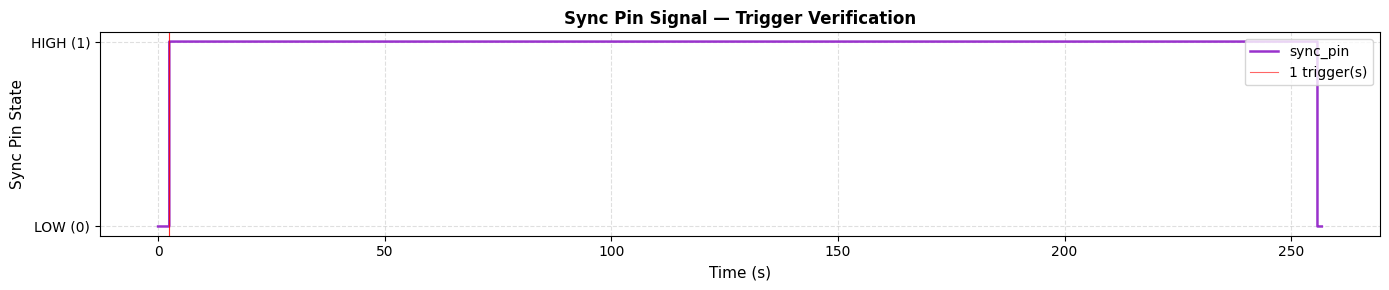

In [23]:
# Cell 21
# ── Sync Pin Verification ─────────────────────────────────────────────────────
# Plots the sync pin channel from encoder CSV to confirm trigger was received.
# Expects a column named 'sync' (or 'sync_pin') in cam_df.

SYNC_COL = next((c for c in cam_df.columns if 'sync' in c.lower()), None)

if SYNC_COL is None:
    print(f" No sync column found. Available columns: {cam_df.columns.tolist()}")
else:
    # Convert to numeric, coerce any non-numeric to NaN
    sync_signal = pd.to_numeric(cam_df[SYNC_COL], errors='coerce').values
    sync_time   = (cam_df['timestamp'] - cam_df['timestamp'].iloc[0]).dt.total_seconds().values

    # Detect edges (LOW→HIGH transitions = trigger events)
    trigger_indices = np.where(np.diff(sync_signal.astype(float)) > 0)[0] + 1
    print(f"Sync column      : '{SYNC_COL}'")
    print(f"Unique values    : {np.unique(sync_signal[~np.isnan(sync_signal)])}")
    print(f"Trigger edges    : {len(trigger_indices)}")
    if len(trigger_indices):
        print(f"First trigger at : {sync_time[trigger_indices[0]]:.3f} s")
        print(f"Last  trigger at : {sync_time[trigger_indices[-1]]:.3f} s")

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.step(sync_time, sync_signal, where='post', color='darkorchid', lw=1.8, label=SYNC_COL)

    # Mark each trigger edge
    for idx in trigger_indices:
        ax.axvline(sync_time[idx], color='red', lw=0.8, alpha=0.6)
    if len(trigger_indices):
        ax.axvline(sync_time[trigger_indices[0]], color='red', lw=0.8, alpha=0.6,
                   label=f'{len(trigger_indices)} trigger(s)')

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Sync Pin State', fontsize=11)
    ax.set_title('Sync Pin Signal — Trigger Verification', fontsize=12, fontweight='bold')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['LOW (0)', 'HIGH (1)'])
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig('sync_pin_verification.png', dpi=150, bbox_inches='tight')
    plt.show()

## LOAD CAMERA CALIBRATION AND BUILD HELPERS

In [24]:
# Cell 22
# ── Load table reference frame only ──────────────────────────────────────────
tbl     = toml.load(TABLE_CALIB_PATH)
R_table = np.array(tbl["rotation_matrix"]).reshape(3, 3)
T_table = np.array(tbl["tvec"]).reshape(3, 1)

# Sanity checks
assert R_table.shape == (3, 3), f"R_table wrong shape: {R_table.shape}"
assert T_table.shape == (3, 1), f"T_table wrong shape: {T_table.shape}"

print("Table rotation R:")
print(np.round(R_table, 4))
print("\nTable translation T (m):", T_table.flatten().round(4))
print("\nShapes OK ✓")

Table rotation R:
[[-9.998e-01  7.000e-04 -2.170e-02]
 [ 1.600e-03 -9.940e-01 -1.094e-01]
 [-2.160e-02 -1.094e-01  9.938e-01]]

Table translation T (m): [-0.0172  0.0208  0.6817]

Shapes OK ✓


## Reconstruct NOARK Position from Camera Data

For each frame we:
1. Take the raw `tvec` / `rvec` for each detected marker (already stored by `Cam_Data_log.py`)
2. Apply the marker-specific physical offset to get the handle position in camera frame
3. Average all available marker positions → **centroid in camera frame**
4. Transform to **table frame**: `P_table = R_table.T @ (P_cam - T_table)`

In [25]:
# Cell 23
# ── Data sanity check ─────────────────────────────────────────────────────────
print("Shape:", cam_df.shape)

print("\n--- NaN counts per marker ---")
for mid in [12, 14, 20]:
    col = f'tvec_{mid}_x'
    print(f"Marker {mid} NaN rows: {cam_df[col].isna().sum()} / {len(cam_df)}")

print("\n--- Rows where ALL 3 markers missing ---")
all_missing = cam_df[['tvec_12_x','tvec_14_x','tvec_20_x']].isna().all(axis=1)
print(f"Count: {all_missing.sum()}")

print("\n--- Rows where ANY marker missing ---")
any_missing = cam_df[['tvec_12_x','tvec_14_x','tvec_20_x']].isna().any(axis=1)
print(f"Count: {any_missing.sum()}")

print("\n--- Sample of raw tvec values (first 10 rows) ---")
print(cam_df[['timestamp','tvec_12_x','tvec_14_x','tvec_20_x']].head(10).to_string())

Shape: (25622, 20)

--- NaN counts per marker ---
Marker 12 NaN rows: 17548 / 25622
Marker 14 NaN rows: 20464 / 25622
Marker 20 NaN rows: 12287 / 25622

--- Rows where ALL 3 markers missing ---
Count: 1729

--- Rows where ANY marker missing ---
Count: 25622

--- Sample of raw tvec values (first 10 rows) ---
                   timestamp  tvec_12_x  tvec_14_x  tvec_20_x
0 2026-05-15 17:12:03.056284        NaN        NaN   0.134587
1 2026-05-15 17:12:03.068626        NaN        NaN   0.134621
2 2026-05-15 17:12:03.073805        NaN        NaN   0.134621
3 2026-05-15 17:12:03.083768        NaN        NaN   0.134587
4 2026-05-15 17:12:03.090595        NaN        NaN   0.134648
5 2026-05-15 17:12:03.101785        NaN        NaN   0.134642
6 2026-05-15 17:12:03.113423        NaN        NaN   0.134674
7 2026-05-15 17:12:03.119851        NaN        NaN   0.134451
8 2026-05-15 17:12:03.131954        NaN        NaN   0.134451
9 2026-05-15 17:12:03.142292        NaN        NaN   0.134609


In [26]:
# Cell 24
def get_centroid_cam(row, marker_ids=MARKER_IDS, offsets=MARKER_OFFSETS):
    """
    Replicates camera_pose.py::_get_centroid().
    Returns centroid in CAMERA frame as (3,1), or None if no marker visible.
    """
    points = []
    for mid in marker_ids:
        tvec_cols = [f"tvec_{mid}_x", f"tvec_{mid}_y", f"tvec_{mid}_z"]
        rvec_cols = [f"rvec_{mid}_x", f"rvec_{mid}_y", f"rvec_{mid}_z"]
        tvec = row[tvec_cols].values.astype(float)
        rvec = row[rvec_cols].values.astype(float)
        if np.any(np.isnan(tvec)) or np.any(np.isnan(rvec)):
            continue
        R_marker, _ = cv2.Rodrigues(rvec)
        offset = offsets[mid].reshape(3, 1)
        pos_cam = R_marker @ offset + tvec.reshape(3, 1)
        points.append(pos_cam.flatten())
    if not points:
        return None
    return np.mean(points, axis=0).reshape(3, 1)


def cam_to_table(p_cam, R_table=R_table, T_table=T_table):
    """
    Replicates camera_pose.py::_get_local_coordinates().
    P_table = R_table.T @ (P_cam - T_table)
    """
    return (R_table.T @ (p_cam - T_table)).flatten()


# Apply row-wise
results = []
for _, row in cam_df.iterrows():
    p_cam = get_centroid_cam(row)
    if p_cam is None:
        results.append([np.nan, np.nan, np.nan])
    else:
        results.append(cam_to_table(p_cam))

pos_cam = pd.DataFrame(results, columns=["x_cam", "y_cam", "z_cam"])
cam_df  = pd.concat([cam_df.reset_index(drop=True), pos_cam], axis=1)

In [27]:
# # See which markers are lost during the missing frames
# missing_mask = cam_df['x_cam'].isna()
# print(cam_df[missing_mask][['tvec_12_x','tvec_14_x','tvec_20_x']].isna().sum())
# # This tells you whether all 3 markers vanish together, or just some

In [28]:
# # # Cell A — Raw camera tvec → table frame (per marker, BEFORE centroid averaging)
# # # ─────────────────────────────────────────────────────────────────────────────
# # # For each ArUco marker in MARKER_IDS, applies the physical offset and
# # # the cam→table transform to get the marker handle position in table frame,
# # # WITHOUT first averaging into a centroid.
# # # Columns added to cam_df:  raw_tf_{mid}_x_m, raw_tf_{mid}_y_m, raw_tf_{mid}_z_m

# def get_marker_in_table(row, mid, R_tbl=R_table, T_tbl=T_table):
#     """
#     Applies cam→table transform directly to raw tvec.
#     NO physical offset applied.
#     """
#     tvec = row[[f"tvec_{mid}_x", f"tvec_{mid}_y", f"tvec_{mid}_z"]].values.astype(float)
#     if np.any(np.isnan(tvec)):
#         return np.array([np.nan, np.nan, np.nan])
#     p_cam = tvec.reshape(3, 1)                           # raw tvec, no offset
#     p_tbl = (R_tbl.T @ (p_cam - T_tbl)).flatten()       # table frame
#     return p_tbl

# for mid in MARKER_IDS:
#     rows_tf = cam_df.apply(lambda r: get_marker_in_table(r, mid), axis=1)
#     cam_df[f'raw_tf_{mid}_x_m'] = rows_tf.apply(lambda v: v[0])
#     cam_df[f'raw_tf_{mid}_y_m'] = rows_tf.apply(lambda v: v[1])
#     cam_df[f'raw_tf_{mid}_z_m'] = rows_tf.apply(lambda v: v[2])

# print("Per-marker table-frame columns added:")
# print("\nSample (first 5 rows, X and Z only):")
# cols_check = [c for c in cam_df.columns if c.startswith('raw_tf_') and c.endswith(('_x_m','_z_m'))]
# print(cam_df[['timestamp'] + cols_check].head(5).round(4).to_string())

In [29]:
# # Cell B — Mocap marker mean vs raw camera→table frame (marker 12 only)

# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker
# import numpy as np
# from scipy.interpolate import interp1d as _interp1d

# MOCAP_MARKERS       = [5, 4, 6, 3]
# CAM_COMPARE_MARKERS = [12]
# # ── 1. Mocap: mean of markers in table frame ──────────────────────────────────
# # Use noark_in_tframe which is already correctly transformed and time-aligned
# noark_key_local = [k for k in rb_dfs.keys() if 'noark' in k.lower()][0]
# df_noark_raw    = rb_dfs[noark_key_local].copy()

# # Get R_mat and t_vec from tframe_dfs (same as Cell 7/28)
# R_mat = tframe_dfs['_R_mat']
# t_vec = tframe_dfs['_t_vec']

# mocap_mean_x, mocap_mean_z = [], []
# for _, row in df_noark_raw.iterrows():
#     pts = []
#     for mn in MOCAP_MARKERS:
#         cx = f'{noark_key_local}_marker_m{mn}_x'
#         cy = f'{noark_key_local}_marker_m{mn}_y'
#         cz = f'{noark_key_local}_marker_m{mn}_z'
#         if cx not in df_noark_raw.columns:
#             continue
#         xyz = np.array([row[cx], row[cy], row[cz]], dtype=float)
#         if np.any(np.isnan(xyz)):
#             continue
#         p_tf = (R_mat.T @ (xyz.reshape(3,1) - t_vec.reshape(3,1))).flatten()
#         pts.append(p_tf)
#     if pts:
#         mean_pt = np.mean(pts, axis=0)
#         mocap_mean_x.append(mean_pt[0] * 100)
#         mocap_mean_z.append(mean_pt[2] * 100)
#     else:
#         mocap_mean_x.append(np.nan)
#         mocap_mean_z.append(np.nan)

# mocap_x_arr = np.array(mocap_mean_x)
# mocap_z_arr = np.array(mocap_mean_z)

# # ── 2. Time alignment — use SAME method as Cell 28 ───────────────────────────
# # Cell 28 uses raw mocap seconds directly onto merged['t_sec']
# # We do the same: use raw seconds onto cam_df['t_sec']
# mocap_t_aligned = df_noark_raw['seconds'].values    # raw Motive seconds — same as Cell 28

# if 't_sec' not in cam_df.columns:
#     cam_df['t_sec'] = (cam_df['timestamp'] - sync_timestamp).dt.total_seconds()
# cam_t_aligned = cam_df['t_sec'].values

# print(f"mocap_t_aligned range : {mocap_t_aligned.min():.3f} → {mocap_t_aligned.max():.3f} s")
# print(f"cam_t_aligned   range : {cam_t_aligned.min():.3f} → {cam_t_aligned.max():.3f} s")

# overlap = (min(mocap_t_aligned[-1], cam_t_aligned[-1])
#          - max(mocap_t_aligned[0],  cam_t_aligned[0]))
# print(f"Overlap : {overlap:.3f} s  {'✓ OK' if overlap > 1.0 else '✗ BAD'}")

# # ── 3. Camera: marker 12 in table frame (from Cell A) ────────────────────────
# raw_x_cols = [f'raw_tf_{mid}_x_m' for mid in CAM_COMPARE_MARKERS
#               if f'raw_tf_{mid}_x_m' in cam_df.columns]
# raw_z_cols = [f'raw_tf_{mid}_z_m' for mid in CAM_COMPARE_MARKERS
#               if f'raw_tf_{mid}_z_m' in cam_df.columns]

# cam_raw_x = cam_df[raw_x_cols].mean(axis=1).values * 100 
# cam_raw_z = cam_df[raw_z_cols].mean(axis=1).values * 100

# print(f"\nmocap X range : {np.nanmin(mocap_x_arr):.2f} → {np.nanmax(mocap_x_arr):.2f} cm")
# print(f"camera X range: {np.nanmin(cam_raw_x):.2f} → {np.nanmax(cam_raw_x):.2f} cm")
# print(f"mocap Z range : {np.nanmin(mocap_z_arr):.2f} → {np.nanmax(mocap_z_arr):.2f} cm")
# print(f"camera Z range: {np.nanmin(cam_raw_z):.2f} → {np.nanmax(cam_raw_z):.2f} cm")

# # ── 4. Interpolate mocap onto camera time grid ────────────────────────────────
# valid_m = ~np.isnan(mocap_x_arr)
# interp_b_x = _interp1d(mocap_t_aligned[valid_m], mocap_x_arr[valid_m],
#                         kind='linear', bounds_error=False, fill_value=np.nan)
# interp_b_z = _interp1d(mocap_t_aligned[valid_m], mocap_z_arr[valid_m],
#                         kind='linear', bounds_error=False, fill_value=np.nan)

# mocap_on_cam_x = interp_b_x(cam_t_aligned)
# mocap_on_cam_z = interp_b_z(cam_t_aligned)

# valid_both = ~np.isnan(cam_raw_x) & ~np.isnan(mocap_on_cam_x)
# print(f"\nCamera frames     : {(~np.isnan(cam_raw_x)).sum()} / {len(cam_raw_x)}")
# print(f"Both valid frames : {valid_both.sum()} / {len(cam_t_aligned)}")

# err_x = (cam_raw_x) - mocap_on_cam_x
# err_z = cam_raw_z - mocap_on_cam_z

# # ── 5. Plot ───────────────────────────────────────────────────────────────────
# t_plot = cam_t_aligned 

# fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
# fig.suptitle(
#     f"Mocap marker mean (m{MOCAP_MARKERS}) vs Raw camera→table frame\n"
#     f"(camera marker 12 only, BEFORE centroid, NO physical offset)",
#     fontsize=13, fontweight='bold'
# )

# ax = axes[0]
# ax.plot(t_plot, cam_raw_x,      color='tomato',    lw=1.4, ls='--', label='Camera raw→tframe X  (marker 12)')
# ax.plot(t_plot, mocap_on_cam_x, color='royalblue', lw=1.8, label=f'Mocap mean X  (m{MOCAP_MARKERS})')
# ax.set_ylabel('X position (cm)', fontsize=11)
# ax.set_title('X axis (left ↔ right)', fontsize=11)
# ax.legend(loc='upper right', fontsize=9)
# ax.grid(True, linestyle='--', alpha=0.4)
# ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# ax = axes[1]
# ax.plot(t_plot, cam_raw_z,      color='darkorange', lw=1.4, ls='--', label='Camera raw→tframe Z  (marker 12)')
# ax.plot(t_plot, mocap_on_cam_z, color='seagreen',   lw=1.8, label=f'Mocap mean Z  (m{MOCAP_MARKERS})')
# ax.set_ylabel('Z position (cm)', fontsize=11)
# ax.set_title('Z axis (up ↕ down)', fontsize=11)
# ax.legend(loc='upper right', fontsize=9)
# ax.grid(True, linestyle='--', alpha=0.4)
# ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# ax = axes[2]
# ax.plot(t_plot[valid_both], err_x[valid_both], color='royalblue', lw=1.2, label='Error X (cam − mocap)')
# ax.plot(t_plot[valid_both], err_z[valid_both], color='seagreen',  lw=1.2, label='Error Z (cam − mocap)')
# ax.axhline(0, color='black', lw=0.8, ls='--')
# ax.set_ylabel('Error (cm)', fontsize=11)
# ax.set_xlabel('Sync-aligned time (s)', fontsize=11)
# ax.set_title('Positional error: camera raw→tframe − mocap mean', fontsize=11)
# ax.legend(loc='upper right', fontsize=9)
# ax.grid(True, linestyle='--', alpha=0.4)
# ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# plt.tight_layout()
# plt.savefig('mocap_mean_vs_cam_raw_tframe.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ── 6. Summary stats ──────────────────────────────────────────────────────────
# if valid_both.sum() > 0:
#     from scipy import stats
#     from scipy.stats import zscore

#     abs_ex = np.abs(err_x[valid_both])
#     abs_ez = np.abs(err_z[valid_both])

#     mean_x = np.mean(abs_ex)
#     mean_z = np.mean(abs_ez)
#     std_x  = np.std(abs_ex)
#     std_z  = np.std(abs_ez)
#     z_95   = stats.norm.ppf(0.95)   # 1.645

#     p95_x  = mean_x + z_95 * std_x
#     p95_z  = mean_z + z_95 * std_z

#     # Max within 95th percentile (excludes top 5% outliers)
#     max_x_95 = abs_ex[abs_ex <= p95_x].max()
#     max_z_95 = abs_ez[abs_ez <= p95_z].max()

#     print(f"\nMAE  X           : {mean_x:.3f} cm")
#     print(f"MAE  Z           : {mean_z:.3f} cm")
#     print(f"RMSE X           : {np.sqrt(np.mean(err_x[valid_both]**2)):.3f} cm")
#     print(f"RMSE Z           : {np.sqrt(np.mean(err_z[valid_both]**2)):.3f} cm")
#     # print(f"95th pct X (z)   : {p95_x:.3f} cm")
#     # print(f"95th pct Z (z)   : {p95_z:.3f} cm")
#     print(f"max abserr X       : {abs_ex.max():.3f} cm ")
#     print(f"max abserr Z       : {abs_ez.max():.3f} cm ")
#     print(f"Max |err X| @95% : {max_x_95:.3f} cm")
#     print(f"Max |err Z| @95% : {max_z_95:.3f} cm")
#     # print(f"Max |err X| all  : {abs_ex.max():.3f} cm")
#     # print(f"Max |err Z| all  : {abs_ez.max():.3f} cm")

#     # z_scores_x = zscore(abs_ex)
#     # z_scores_z = zscore(abs_ez)

#     # # Points within 95th percentile → z-score < 1.645
#     # mask_95_x = z_scores_x < z_95
#     # mask_95_z = z_scores_z < z_95

#     # max_x_95 = np.nanmax(abs_ex[mask_95_x])
#     # max_z_95 = np.nanmax(abs_ez[mask_95_z])

#     # print(f"Max |err X| @95% (zscore) : {max_x_95:.3f} cm")
#     # print(f"Max |err Z| @95% (zscore) : {max_z_95:.3f} cm")





In [30]:
# # ── Mocap marker distances (physical separation between marker pairs) ─────────
# MARKER_PAIRS = [(5, 4), (5, 6), (4, 3), (6, 3)]

# print("Mean distance between mocap marker pairs (in mocap raw frame):")
# print(f"{'Pair':>10}  {'Mean (cm)':>10}  {'Std (cm)':>10}  {'Min (cm)':>10}  {'Max (cm)':>10}")
# print("-" * 55)

# for (m1, m2) in MARKER_PAIRS:
#     c1 = [f'{noark_key_local}_marker_m{m1}_x',
#           f'{noark_key_local}_marker_m{m1}_y',
#           f'{noark_key_local}_marker_m{m1}_z']
#     c2 = [f'{noark_key_local}_marker_m{m2}_x',
#           f'{noark_key_local}_marker_m{m2}_y',
#           f'{noark_key_local}_marker_m{m2}_z']

#     if c1[0] not in df_noark_raw.columns or c2[0] not in df_noark_raw.columns:
#         print(f"  m{m1}-m{m2}: columns not found")
#         continue

#     p1 = df_noark_raw[c1].values.astype(float)
#     p2 = df_noark_raw[c2].values.astype(float)

#     # Valid rows where both markers are present
#     valid = ~np.isnan(p1).any(axis=1) & ~np.isnan(p2).any(axis=1)
#     dist  = np.linalg.norm(p1[valid] - p2[valid], axis=1) * 100  # → cm

#     print(f"  m{m1}-m{m2}  :  {dist.mean():>9.3f}  {dist.std():>10.3f}  {dist.min():>10.3f}  {dist.max():>10.3f}")

## Reconstruct NOARK Position from Encoder Data

Replicates the kinematics in `nkin.py`:
1. At the **zero event** (first encoder row), capture camera-derived free lengths `P2_to_NOARK_init` and `P4_to_NOARK_init`
2. For each encoder tick: `L_free_L = init_L + r_ML * deg2rad(enc1)`, `L_free_R = init_R - r_MR * deg2rad(enc2)`
3. Solve **circle–circle intersection** between `P2` (radius `L_free_L`) and `P4` (radius `L_free_R`) to get `(x, z)` in table frame

In [31]:
# Cell 25
# Find the zero-reference using camera position at sync moment (t_sec = 0)
sync_row = cam_df[cam_df['sync_pin'] == 1].iloc[0]  # first frame where sync pin is HIGH
N0 = np.array([sync_row["x_cam"], 0, sync_row["z_cam"]])

P2_to_NOARK_init = sqrt((N0[0] - P2[0])**2 + (N0[2] - P2[2])**2)
P4_to_NOARK_init = sqrt((N0[0] - P4[0])**2 + (N0[2] - P4[2])**2)

print(f"Init position (table frame) at sync:  x={N0[0]*100:.2f} cm   z={N0[2]*100:.2f} cm")
print(f"P2_to_NOARK_init: {P2_to_NOARK_init*100:.2f} cm")
print(f"P4_to_NOARK_init: {P4_to_NOARK_init*100:.2f} cm")

Init position (table frame) at sync:  x=-27.85 cm   z=-9.68 cm
P2_to_NOARK_init: 22.75 cm
P4_to_NOARK_init: 77.66 cm


In [32]:
# # Cell — MoCap Init Position + Distance to P2 and P4
# from math import sqrt

# _nm  = tframe_dfs['_noark_marker']
# df_n = tframe_dfs['noark_in_tframe'].copy()
# df_t = tframe_dfs['table_in_tframe'].copy()

# # ── Initial NOARK position (first frame) ─────────────────────────────────────
# xcol = f'noark_m{_nm}_tf_x_m'
# zcol = f'noark_m{_nm}_tf_z_m'

# N0_mocap = np.array([df_n.loc[0, xcol], 0, df_n.loc[0, zcol]])
# print(f"Init position (tframe)_mocap_data:  x={N0_mocap[0]*100:.2f} cm   z={N0_mocap[2]*100:.2f} cm")

# # ── P2 and P4 pulley positions from table markers (tframe, first frame) ───────
# # From notes: table_marker_6 = P2 (left pulley), table_marker_5 = P4 (right pulley)
# # P2_mocap = np.array([df_t.loc[0, 'table_m6_tf_x_m'], 0, df_t.loc[0, 'table_m6_tf_z_m']])
# # P4_mocap = np.array([df_t.loc[0, 'table_m5_tf_x_m'], 0, df_t.loc[0, 'table_m5_tf_z_m']])
# P2_mocap = np.array([df_t['table_m1_tf_x_m'].mean(), 0, df_t['table_m1_tf_z_m'].mean()])
# P4_mocap = np.array([df_t['table_m3_tf_x_m'].mean(), 0, df_t['table_m3_tf_z_m'].mean()])
# print(f"P2 position (tframe)_mocap_data:  x={P2_mocap[0]*100:.2f} cm   z={P2_mocap[2]*100:.2f} cm")
# print(f"P4 position (tframe)_mocap_data:  x={P4_mocap[0]*100:.2f} cm   z={P4_mocap[2]*100:.2f} cm")
# # ── Distances (same formula as Cell 25) ──────────────────────────────────────
# P2_to_NOARK_init_mocap = sqrt((N0_mocap[0] - P2_mocap[0])**2 + (N0_mocap[2] - P2_mocap[2])**2)
# P4_to_NOARK_init_mocap = sqrt((N0_mocap[0] - P4_mocap[0])**2 + (N0_mocap[2] - P4_mocap[2])**2)

# print(f"P2_to_NOARK_init_mocap: {P2_to_NOARK_init_mocap*100:.2f} cm")
# print(f"P4_to_NOARK_init_mocap: {P4_to_NOARK_init_mocap*100:.2f} cm")

In [33]:
# Cell 26
#  Circle-circle intersection (ENCODER) ────────────────────────────────

def circle_intersect_xz(p2, p4, r_l, r_r):
    """
    Finds the intersection of two circles in the X-Z plane.
    p2, p4 : 3-element arrays, only [0] (X) and [2] (Z) are used
    r_l    : radius of circle centred at p2  (left cable free length)
    r_r    : radius of circle centred at p4  (right cable free length)
    Returns (x, z) of the 'upper' solution (enc_1 in nkin.py), or (nan, nan).
    """
    # x2, z2 = p2[0], p2[2] #camera-based pulley positions from table markers (tframe, first frame)
    # x4, z4 = p4[0], p4[2] #camera-based pulley positions from table markers (tframe, first frame)
    x2, z2 = p2[0], p2[2] #mocap-based pulley positions from table markers (tframe, first frame)
    x4, z4 = p4[0], p4[2] #mocap-based pulley positions from table markers (tframe, first frame)
    d = sqrt((x4 - x2)**2 + (z4 - z2)**2)

    # Triangle feasibility check
    if d > r_l + r_r or d < abs(r_l - r_r) or d == 0:
        return np.nan, np.nan

    a  = (r_l**2 - r_r**2 + d**2) / (2 * d)
    h2 = r_l**2 - a**2
    if h2 < 0:
        return np.nan, np.nan
    h = sqrt(h2)

    xm = x2 + a * (x4 - x2) / d
    zm = z2 + a * (z4 - z2) / d

    # 'enc_1' solution — matches nkin.py x_enc_1 / z_enc_1
    x_sol = xm + h * (z4 - z2) / d
    z_sol = zm - h * (x4 - x2) / d
    return x_sol, z_sol


# ── Step 4c: Compute encoder-based positions ──────────────────────────────────
x_enc_list, z_enc_list = [], []

for _, row in enc_df.iterrows():
    delta_L = r_ML * np.deg2rad(float(row["enc1"]))
    delta_R = r_MR * np.deg2rad(float(row["enc2"]))

    L_free_L = P2_to_NOARK_init + delta_L  # using camera-based init distances as reference
    L_free_R = P4_to_NOARK_init - delta_R  # using camera-based init distances as reference  
    
    
    # L_free_L = P2_to_NOARK_init_mocap + delta_L  # using mocap -based init distances as reference
    # L_free_R = P4_to_NOARK_init_mocap - delta_R  # using mocap -based init distances as reference
  
    # x_e, z_e = circle_intersect_xz(P2_mocap, P4_mocap, L_free_L, L_free_R)
    x_e, z_e = circle_intersect_xz(P2, P4, L_free_L, L_free_R)
    x_enc_list.append(x_e)
    z_enc_list.append(z_e)

enc_df["x_enc"] = x_enc_list
enc_df["z_enc"] = z_enc_list

print(f"Valid encoder frames: {enc_df['x_enc'].notna().sum()} / {len(enc_df)}")
enc_df[["timestamp", "enc1", "enc2", "x_enc", "z_enc"]].head(5).round(4)

Valid encoder frames: 127958 / 127958


,timestamp,enc1,enc2,x_enc,z_enc
0,2026-05-15 17:12:03.031148,0.0,0.0,-0.2785,-0.0968
1,2026-05-15 17:12:03.032712,0.0,0.0,-0.2785,-0.0968
2,2026-05-15 17:12:03.034707,0.0,0.0,-0.2785,-0.0968
3,2026-05-15 17:12:03.036736,0.0,0.0,-0.2785,-0.0968
4,2026-05-15 17:12:03.038813,0.0,0.0,-0.2785,-0.0968


## Time-Align Camera and Encoder Signals

Both CSVs use wall-clock timestamps. We align them by interpolating encoder onto the camera time grid.

In [71]:
# Cell 27
# ── Use sync pin timestamp as the single common t0 for all signals ────────────
cam_df['timestamp'] = pd.to_datetime(cam_df['timestamp'])
enc_df['timestamp'] = pd.to_datetime(enc_df['timestamp'])

# t0 is now the hardware sync moment — not an arbitrary CSV start
t0 = sync_timestamp

cam_df['t_sec'] = (cam_df['timestamp'] - t0).dt.total_seconds()
enc_df['t_sec'] = (enc_df['timestamp'] - t0).dt.total_seconds()

# Keep only rows from sync onward (t_sec >= 0) for camera
# Encoder rows before sync are kept — they define the init cable lengths
cam_sync = cam_df[cam_df['t_sec'] >= 0].sort_values('t_sec').reset_index(drop=True)
enc_s = enc_df[enc_df['t_sec'] >= 0] \
            .sort_values('t_sec') \
            .reset_index(drop=True)

print(f"Camera frames before sync (dropped) : {(cam_df['t_sec'] < 0).sum()}")
print(f"Camera frames from sync onward      : {len(cam_sync)}")
print(f"Encoder frames total                : {len(enc_s)}")
print(f"t_sec=0 is now the sync pin moment  : {sync_timestamp}")
# ← ONLY CHANGE: exclude NaN rows before interp1d
enc_s_valid = enc_s[enc_s['x_enc'].notna() & enc_s['z_enc'].notna()]
print(f"Valid encoder frames (non-NaN)      : {len(enc_s_valid)} / {len(enc_s)}")
interp_x = interp1d(enc_s_valid['t_sec'], enc_s_valid['x_enc'],
                    kind='linear', bounds_error=False, fill_value=np.nan)
interp_z = interp1d(enc_s['t_sec'], enc_s['z_enc'],
                    kind='linear', bounds_error=False, fill_value=np.nan)

merged = cam_sync.copy()
merged['x_enc'] = interp_x(merged['t_sec'])
merged['z_enc'] = interp_z(merged['t_sec'])

for col in ['x_cam', 'z_cam', 'x_enc', 'z_enc']:
    merged[col + '_cm'] = merged[col] * 100

print(f"\nTotal merged frames  : {len(merged)}")
print(f"Valid cam frames     : {merged['x_cam'].notna().sum()}")
print(f"Valid encoder frames : {merged['x_enc'].notna().sum()}")
merged[['t_sec', 'x_cam_cm', 'z_cam_cm', 'x_enc_cm', 'z_enc_cm']].head(5).round(3)


Camera frames before sync (dropped) : 248
Camera frames from sync onward      : 25374
Encoder frames total                : 126711
t_sec=0 is now the sync pin moment  : 2026-05-15 17:12:05.531474
Valid encoder frames (non-NaN)      : 126711 / 126711

Total merged frames  : 25374
Valid cam frames     : 23645
Valid encoder frames : 25372


,t_sec,x_cam_cm,z_cam_cm,x_enc_cm,z_enc_cm
0,0.000,-27.851,-9.675,NaN,NaN
1,0.008,-27.857,-9.680,-27.852,-9.679
2,0.019,-27.853,-9.614,-27.852,-9.679
3,0.031,-27.859,-9.657,-27.852,-9.679
4,0.038,-27.857,-9.653,-27.852,-9.679


# ── Mocap time alignment using sync pin ───────────────────────────────────────
# noark_st_time = wall-clock time when Motive started saving (triggered by sync pin)
# sync_timestamp = wall-clock time of the sync pin rising edge in camera CSV
# These should be nearly identical — offset_sec should be close to 0

In [72]:
# Cell 28
# ── Extract mocap position arrays in cm ───────────────────────────────────────
df_mocap = tframe_dfs['noark_in_tframe'].copy()
_nm = tframe_dfs['_noark_marker'] 

_mask   = df_mocap[f'noark_m{_nm}_tf_x_m'].notna() & df_mocap[f'noark_m{_nm}_tf_z_m'].notna()
# mocap_t = df_mocap.loc[_mask, 'seconds'].values
# mocap_x = df_mocap.loc[_mask, f'noark_m{_nm}_tf_x_m'].values * 100.0
# mocap_z = df_mocap.loc[_mask, f'noark_m{_nm}_tf_z_m'].values * 100.0


print(f"Mocap frames : {len(mocap_t)}  (from {len(df_mocap)} total, {len(df_mocap)-len(mocap_t)} NaN rows dropped)")
print(f"Mocap X range: {mocap_x.min():.2f} → {mocap_x.max():.2f} cm")
print(f"Mocap Z range: {mocap_z.min():.2f} → {mocap_z.max():.2f} cm")

# ── Interpolate onto merged time grid ─────────────────────────────────────────
interp_mocap_x = interp1d(mocap_t, mocap_x, kind='linear', bounds_error=False, fill_value=np.nan)
interp_mocap_z = interp1d(mocap_t, mocap_z, kind='linear', bounds_error=False, fill_value=np.nan)

merged['mocap_x'] = interp_mocap_x(merged['t_sec'])
merged['mocap_z'] = interp_mocap_z(merged['t_sec'])

valid_mocap = merged['mocap_x'].notna().sum()
print(f"\nValid mocap frames: {valid_mocap} / {len(merged)}")

overlap = min(mocap_t[-1], merged['t_sec'].iloc[-1]) - max(mocap_t[0], merged['t_sec'].iloc[0])
print(f"Overlap : {overlap:.3f} s  {'✓ OK' if overlap > 1.0 else '✗ BAD — check time origins!'}")

merged[['t_sec', 'x_cam_cm', 'z_cam_cm', 'x_enc_cm', 'z_enc_cm',
        'mocap_x', 'mocap_z']].head(5).round(3)

Mocap frames : 25316  (from 25316 total, 0 NaN rows dropped)
Mocap X range: nan → nan cm
Mocap Z range: nan → nan cm

Valid mocap frames: 25258 / 25374
Overlap : 253.150 s  ✓ OK


,t_sec,x_cam_cm,z_cam_cm,x_enc_cm,z_enc_cm,mocap_x,mocap_z
0,0.000,-27.851,-9.675,NaN,NaN,-27.801,-11.597
1,0.008,-27.857,-9.680,-27.852,-9.679,-27.800,-11.598
2,0.019,-27.853,-9.614,-27.852,-9.679,-27.800,-11.597
3,0.031,-27.859,-9.657,-27.852,-9.679,-27.801,-11.598
4,0.038,-27.857,-9.653,-27.852,-9.679,-27.801,-11.598


In [73]:
# Cell 28b — First-frame alignment check (inspection only, no correction)

first_valid_enc = merged[
    merged['x_enc_cm'].notna() & merged['mocap_x'].notna()
].index[0]

first_valid_cam = merged[
    merged['x_cam_cm'].notna() & merged['mocap_x'].notna()
].index[0]

print(f"Encoder at first valid: X={merged.loc[first_valid_enc, 'x_enc_cm']:.3f}  Z={merged.loc[first_valid_enc, 'z_enc_cm']:.3f}")
print(f"Mocap   at first valid: X={merged.loc[first_valid_enc, 'mocap_x']:.3f}  Z={merged.loc[first_valid_enc, 'mocap_z']:.3f}")
print()
print(f"Camera  at first valid: X={merged.loc[first_valid_cam, 'x_cam_cm']:.3f}  Z={merged.loc[first_valid_cam, 'z_cam_cm']:.3f}")
print(f"Mocap   at first valid: X={merged.loc[first_valid_cam, 'mocap_x']:.3f}  Z={merged.loc[first_valid_cam, 'mocap_z']:.3f}")

Encoder at first valid: X=-27.852  Z=-9.679
Mocap   at first valid: X=-27.800  Z=-11.598

Camera  at first valid: X=-27.851  Z=-9.675
Mocap   at first valid: X=-27.801  Z=-11.597


In [74]:
# ── Time alignment diagnostic (run after Cell 28) ────────────────────────────

# 1. Sync pin and MoCap start times
print(f"Sync pin wall-clock time     : {sync_timestamp}")
print(f"MoCap recording start (wall) : {noark_st_time}")
mocap_time_offset = (noark_st_time - sync_timestamp).total_seconds()
print(f"MoCap started {mocap_time_offset:.3f} s AFTER sync pin")
print()
print(f"MoCap start wall time : {noark_st_time}")
print(f"MoCap end wall time   : {noark_st_time + pd.Timedelta(seconds=48.52)}")
print(f"Sync pin wall time    : {sync_timestamp}")
print(f"Experiment end time   : {sync_timestamp + pd.Timedelta(seconds=49.65)}")
# 2. Time ranges
print(f"merged t_sec range           : {merged['t_sec'].min():.3f} → {merged['t_sec'].max():.3f} s")
print(f"mocap_t range (raw seconds)  : {mocap_t.min():.3f} → {mocap_t.max():.3f} s")
print()

# 3. Overlap check — raw vs aligned
raw_overlap = (min(mocap_t[-1], merged['t_sec'].iloc[-1])
             - max(mocap_t[0],  merged['t_sec'].iloc[0]))
aligned_mocap_t = mocap_t + mocap_time_offset
aligned_overlap = (min(aligned_mocap_t[-1], merged['t_sec'].iloc[-1])
                 - max(aligned_mocap_t[0],  merged['t_sec'].iloc[0]))

print(f"Overlap using RAW mocap_t    : {raw_overlap:.3f} s  {'✓' if raw_overlap > 1 else '✗ BAD'}")
print(f"Overlap using ALIGNED mocap_t: {aligned_overlap:.3f} s  {'✓' if aligned_overlap > 1 else '✗ BAD'}")
print()

# 4. Spot check first 5 rows
print("First 5 merged rows:")
print(merged[['t_sec', 'mocap_x', 'mocap_z',
              'x_enc_cm', 'z_enc_cm']].head(5).round(3).to_string())

Sync pin wall-clock time     : 2026-05-15 17:12:05.531474
MoCap recording start (wall) : 2026-05-15 17:12:04.138000
MoCap started -1.393 s AFTER sync pin

MoCap start wall time : 2026-05-15 17:12:04.138000
MoCap end wall time   : 2026-05-15 17:12:52.658000
Sync pin wall time    : 2026-05-15 17:12:05.531474
Experiment end time   : 2026-05-15 17:12:55.181474
merged t_sec range           : 0.000 → 254.286 s
mocap_t range (raw seconds)  : 0.000 → 253.150 s

Overlap using RAW mocap_t    : 253.150 s  ✓
Overlap using ALIGNED mocap_t: 251.757 s  ✓

First 5 merged rows:
   t_sec  mocap_x  mocap_z  x_enc_cm  z_enc_cm
0  0.000  -27.801  -11.597       NaN       NaN
1  0.008  -27.800  -11.598   -27.852    -9.679
2  0.019  -27.800  -11.597   -27.852    -9.679
3  0.031  -27.801  -11.598   -27.852    -9.679
4  0.038  -27.801  -11.598   -27.852    -9.679


In [75]:
# ── Check coordinate system offset at first valid frame ──────────────────────
idx = merged['mocap_x'].first_valid_index()
print("First valid frame comparison:")
print(f"  Mocap  X={merged.loc[idx,'mocap_x']:.3f}  Z={merged.loc[idx,'mocap_z']:.3f} cm")
print(f"  Camera X={merged.loc[idx,'x_cam_cm']:.3f}  Z={merged.loc[idx,'z_cam_cm']:.3f} cm")
print(f"  Offset X={merged.loc[idx,'x_cam_cm']-merged.loc[idx,'mocap_x']:.3f} cm")
print(f"  Offset Z={merged.loc[idx,'z_cam_cm']-merged.loc[idx,'mocap_z']:.3f} cm")

# ── Check if offset is constant throughout ────────────────────────────────────
valid = merged['mocap_x'].notna() & merged['x_cam_cm'].notna()
offset_x = (merged.loc[valid,'x_cam_cm'] - merged.loc[valid,'mocap_x'])
offset_z = (merged.loc[valid,'z_cam_cm'] - merged.loc[valid,'mocap_z'])
print(f"\nOffset X: mean={offset_x.mean():.3f}  std={offset_x.std():.3f} cm")
print(f"Offset Z: mean={offset_z.mean():.3f}  std={offset_z.std():.3f} cm")
print(f"\nIf std is small (< 0.5 cm), offset is constant → coordinate system mismatch")
print(f"If std is large (> 1.0 cm), offset varies → calibration quality issue")

First valid frame comparison:
  Mocap  X=-27.801  Z=-11.597 cm
  Camera X=-27.851  Z=-9.675 cm
  Offset X=-0.050 cm
  Offset Z=1.922 cm

Offset X: mean=-0.145  std=0.500 cm
Offset Z: mean=0.275  std=0.812 cm

If std is small (< 0.5 cm), offset is constant → coordinate system mismatch
If std is large (> 1.0 cm), offset varies → calibration quality issue


## ERROR STATISTICS — Camera vs Encoder

In [76]:
# ── Reusable summary stats function ──────────────────────────────────────────
from scipy import stats
from scipy.stats import zscore

def print_summary_stats(err_x, err_z, label=''):
    abs_ex = np.abs(err_x)
    abs_ez = np.abs(err_z)

    mean_x = np.mean(abs_ex)
    mean_z = np.mean(abs_ez)
    std_x  = np.std(abs_ex)
    std_z  = np.std(abs_ez)
    z_95   = stats.norm.ppf(0.95)   # 1.645

    p95_x  = mean_x + z_95 * std_x
    p95_z  = mean_z + z_95 * std_z

    z_scores_x = zscore(abs_ex)
    z_scores_z = zscore(abs_ez)
    mask_95_x  = z_scores_x < z_95
    mask_95_z  = z_scores_z < z_95

    max_x_95 = np.nanmax(abs_ex[mask_95_x])
    max_z_95 = np.nanmax(abs_ez[mask_95_z])

    header = f"\n{'─'*40}\n  {label}\n{'─'*40}" if label else ''
    print(header)
    print(f"MAE  X              : {mean_x:.3f} cm")
    print(f"MAE  Z              : {mean_z:.3f} cm")
    print(f"RMSE X              : {np.sqrt(np.mean(err_x**2)):.3f} cm")
    print(f"RMSE Z              : {np.sqrt(np.mean(err_z**2)):.3f} cm")
    print(f"Max |err X|         : {abs_ex.max():.3f} cm")
    print(f"Max |err Z|         : {abs_ez.max():.3f} cm")
    print(f"Max |err X| @95%    : {max_x_95:.3f} cm")
    print(f"Max |err Z| @95%    : {max_z_95:.3f} cm")

In [77]:
# ── Compute raw error columns ─────────────────────────────────────────────────
# Camera vs encoder
merged["err_x_cm"] = merged["x_enc_cm"] - merged["x_cam_cm"]
merged["err_z_cm"] = merged["z_enc_cm"] - merged["z_cam_cm"]

err_x = merged["err_x_cm"].to_numpy()
err_z = merged["err_z_cm"].to_numpy()

mask        = ~np.isnan(err_x) & ~np.isnan(err_z)
err_x_valid = err_x[mask]
err_z_valid = err_z[mask]

def arr_stats(arr, name):
    print(f"{name:15s}  mean={arr.mean():.3f}  std={arr.std():.3f}"
          f"min={arr.min():.3f}  max={arr.max():.3f}  "
          f"RMSE={np.sqrt((arr**2).mean()):.3f}  "
          f"95th={np.percentile(arr, 95):.3f}")

print(f"Valid frames : {mask.sum()} / {len(mask)}")
# arr_stats(err_x_valid, "err_x_cm")
# arr_stats(err_z_valid, "err_z_cm")
# print()
# print(f"Mean absolute error X : {np.mean(np.abs(err_x_valid)):.3f} cm")
# print(f"Mean absolute error Z : {np.mean(np.abs(err_z_valid)):.3f} cm")
# print(f"Max absolute error X  : {np.max(np.abs(err_x_valid)):.3f} cm")
# print(f"Max absolute error Z  : {np.max(np.abs(err_z_valid)):.3f} cm")
print_summary_stats(err_x_valid, err_z_valid, label='Camera vs Encoder')

Valid frames : 23643 / 25374

────────────────────────────────────────
  Camera vs Encoder
────────────────────────────────────────
MAE  X              : 1.287 cm
MAE  Z              : 1.543 cm
RMSE X              : 1.913 cm
RMSE Z              : 2.592 cm
Max |err X|         : 12.220 cm
Max |err Z|         : 19.467 cm
Max |err X| @95%    : 3.615 cm
Max |err Z| @95%    : 4.968 cm


## Plot 1: Time-Series Comparison — Camera vs Encoder

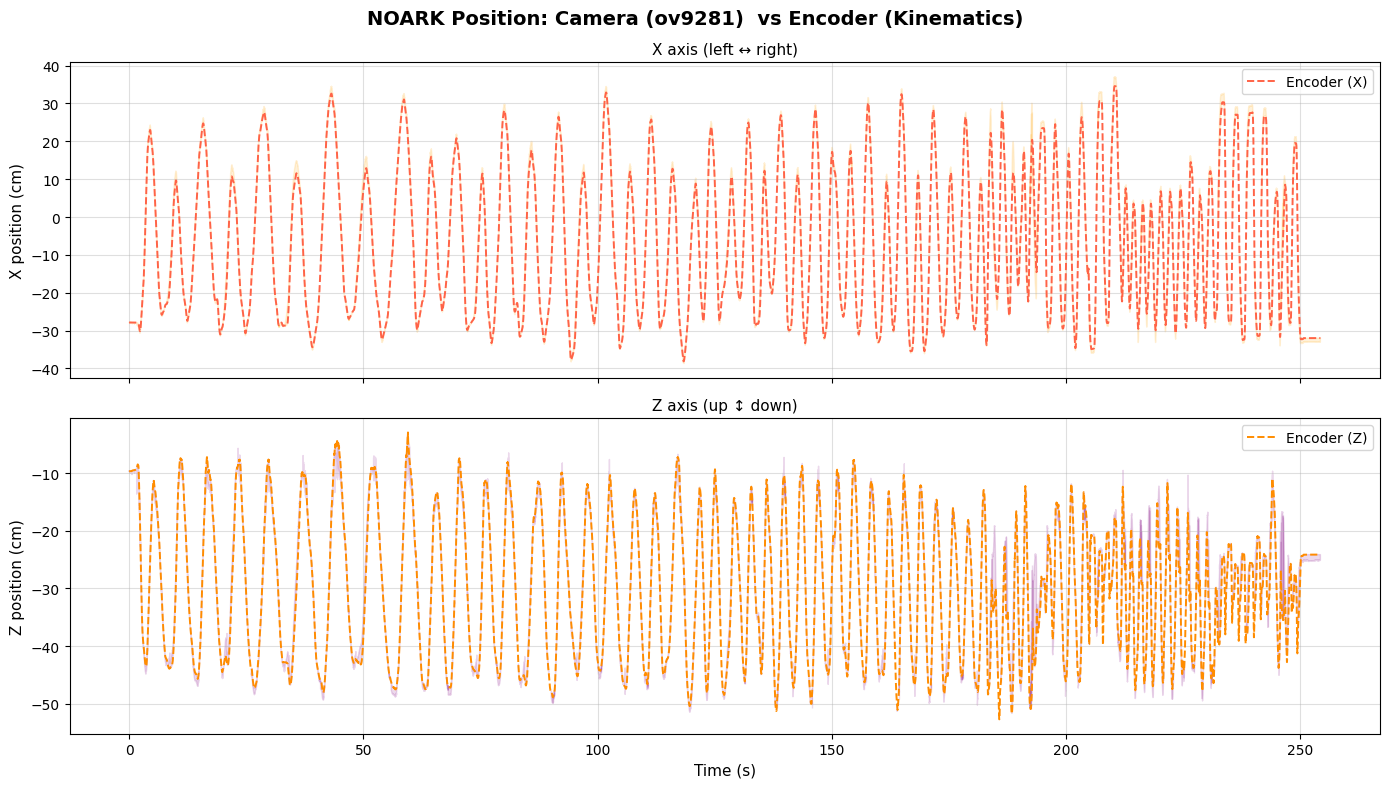

Saved: plot1_timeseries.png


In [78]:
# Cell 32
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("NOARK Position: Camera (ov9281)  vs Encoder (Kinematics)", fontsize=14, fontweight='bold')

t = merged["t_sec"]

ax = axes[0]
# ax.plot(t, merged["x_cam_cm"], color="steelblue",  lw=1.8, label="Camera  (X)")
ax.plot(t, merged["x_enc_cm"], color="tomato",     lw=1.4, ls="--", label="Encoder (X)")
ax.fill_between(t, merged["x_cam_cm"], merged["x_enc_cm"], alpha=0.15, color="orange")
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X axis (left ↔ right)", fontsize=11)

ax = axes[1]
# ax.plot(t, merged["z_cam_cm"], color="seagreen",   lw=1.8, label="Camera  (Z)")
ax.plot(t, merged["z_enc_cm"], color="darkorange", lw=1.4, ls="--", label="Encoder (Z)")
ax.fill_between(t, merged["z_cam_cm"], merged["z_enc_cm"], alpha=0.15, color="purple")
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z axis (up ↕ down)", fontsize=11)

plt.tight_layout()
plt.savefig(repo_root / "vaideesh" / "Analysis" / "plot1_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot1_timeseries.png")

## Plot 2: 2D Trajectory + Error Box Plot — Camera vs Encoder

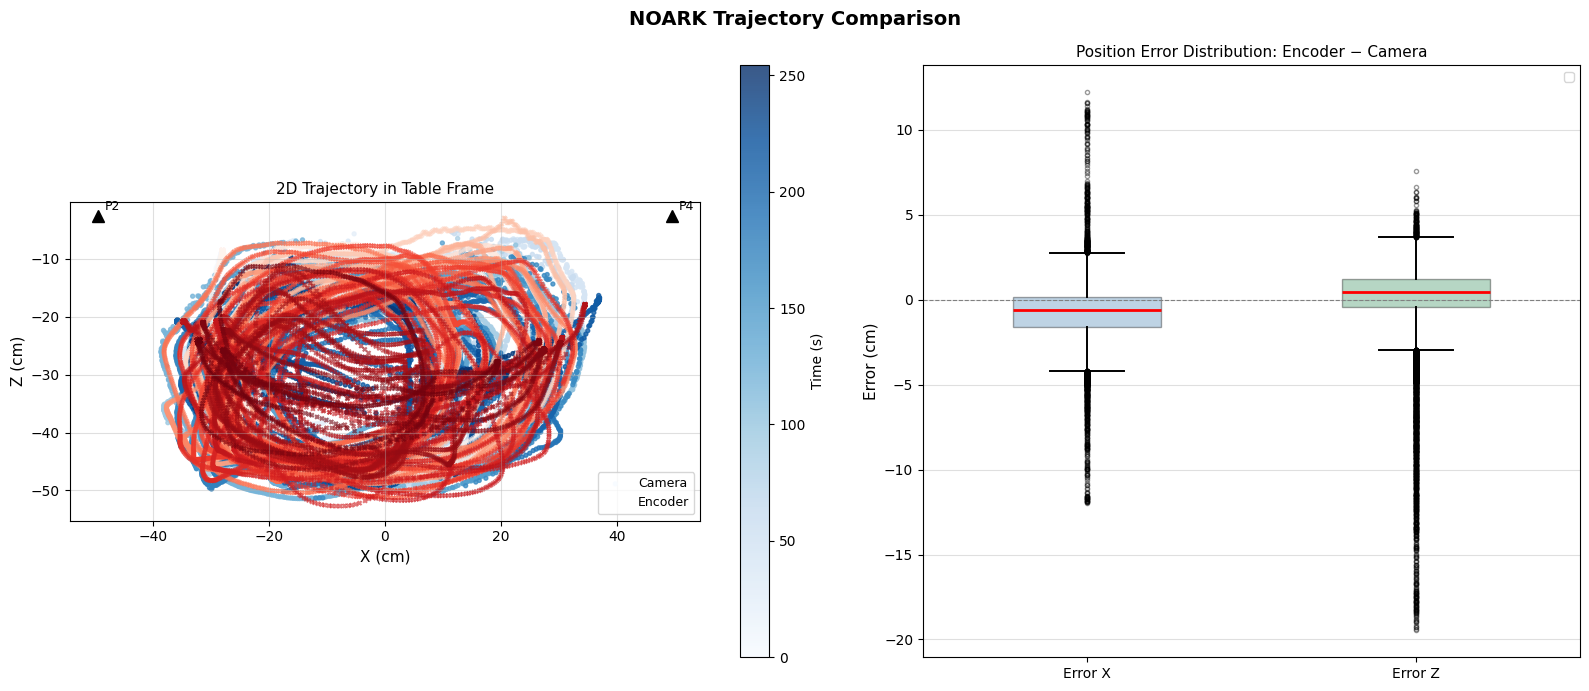

In [79]:
# Cell 33
fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle("NOARK Trajectory Comparison", fontsize=14, fontweight='bold')

# ── Left panel: 2D trajectory in X-Z table frame ─────────────────────────────
ax1 = fig.add_subplot(gs[0])
sc_cam = ax1.scatter(merged["x_cam_cm"], merged["z_cam_cm"],
                     c=merged["t_sec"], cmap="Blues", s=8, alpha=0.8, label="Camera")
sc_enc = ax1.scatter(merged["x_enc_cm"], merged["z_enc_cm"],
                     c=merged["t_sec"], cmap="Reds",  s=8, alpha=0.6, label="Encoder", marker="x")

for name, pt in [("P2", P2), ("P4", P4)]:
    ax1.plot(pt[0]*100, pt[2]*100, "k^", ms=8)
    ax1.annotate(name, (pt[0]*100, pt[2]*100), textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.colorbar(sc_cam, ax=ax1, label="Time (s)")
ax1.set_xlabel("X (cm)", fontsize=11)
ax1.set_ylabel("Z (cm)", fontsize=11)
ax1.set_title("2D Trajectory in Table Frame", fontsize=11)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True, alpha=0.4)
ax1.set_aspect("equal", adjustable="box")

# ── Right panel: Box plot of position errors ──────────────────────────────────
ax2 = fig.add_subplot(gs[1])

error_data = [err_x_valid, err_z_valid]
labels      = ["Error X", "Error Z"]
colors      = ["steelblue", "seagreen"]

bp = ax2.boxplot(
    error_data,
    labels=labels,
    patch_artist=True,
    notch=False,
    widths=0.45,
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker="o", markersize=3, linestyle="none", alpha=0.4),
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

ax2.axhline(0, color="grey", lw=0.8, ls="--")
ax2.set_ylabel("Error (cm)", fontsize=11)
ax2.set_title("Position Error Distribution: Encoder − Camera", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4, axis="y")

plt.tight_layout()
plt.savefig(repo_root / "vaideesh" / "Analysis" / "plot2_trajectory_error.png", dpi=150, bbox_inches="tight")
plt.show()

## ERROR STATISTICS — Mocap vs Camera

In [80]:
# Cell 34
# ── Mocap vs Camera errors ────────────────────────────────────────────────────
merged['err_mc_x_cm'] = merged['x_cam_cm'] - merged['mocap_x']
merged['err_mc_z_cm'] = merged['z_cam_cm'] - merged['mocap_z']

mask_mc = merged['err_mc_x_cm'].notna() & merged['err_mc_z_cm'].notna()

err_mc_x  = merged['err_mc_x_cm'][mask_mc].to_numpy()
err_mc_z  = merged['err_mc_z_cm'][mask_mc].to_numpy()

print(f"Valid frames : {mask_mc.sum()} / {len(merged)}")
print(f"x_mocap_cm valid : {merged['mocap_x'].notna().sum()}")
print(f"x_cam_cm   valid : {merged['x_cam_cm'].notna().sum()}")
print(f"Both valid       : {(merged['mocap_x'].notna() & merged['x_cam_cm'].notna()).sum()}")
print()

# arr_stats(err_mc_x,  "err_mc_x_cm")
# arr_stats(err_mc_z,  "err_mc_z_cm")
# print()

# print(f"Mean absolute error X : {np.mean(np.abs(err_mc_x)):.3f} cm")
# print(f"Mean absolute error Z : {np.mean(np.abs(err_mc_z)):.3f} cm")

# print(f"Max absolute error X  : {np.max(np.abs(err_mc_x)):.3f} cm")
# print(f"Max absolute error Z  : {np.max(np.abs(err_mc_z)):.3f} cm")
print_summary_stats(err_mc_x, err_mc_z, label='Mocap vs Camera')

Valid frames : 23529 / 25374
x_mocap_cm valid : 25258
x_cam_cm   valid : 23645
Both valid       : 23529


────────────────────────────────────────
  Mocap vs Camera
────────────────────────────────────────
MAE  X              : 0.398 cm
MAE  Z              : 0.669 cm
RMSE X              : 0.521 cm
RMSE Z              : 0.858 cm
Max |err X|         : 3.147 cm
Max |err Z|         : 6.405 cm
Max |err X| @95%    : 0.950 cm
Max |err Z| @95%    : 1.552 cm


2D Trajectory + Error Box Plot: Mocap (GT) vs Camera

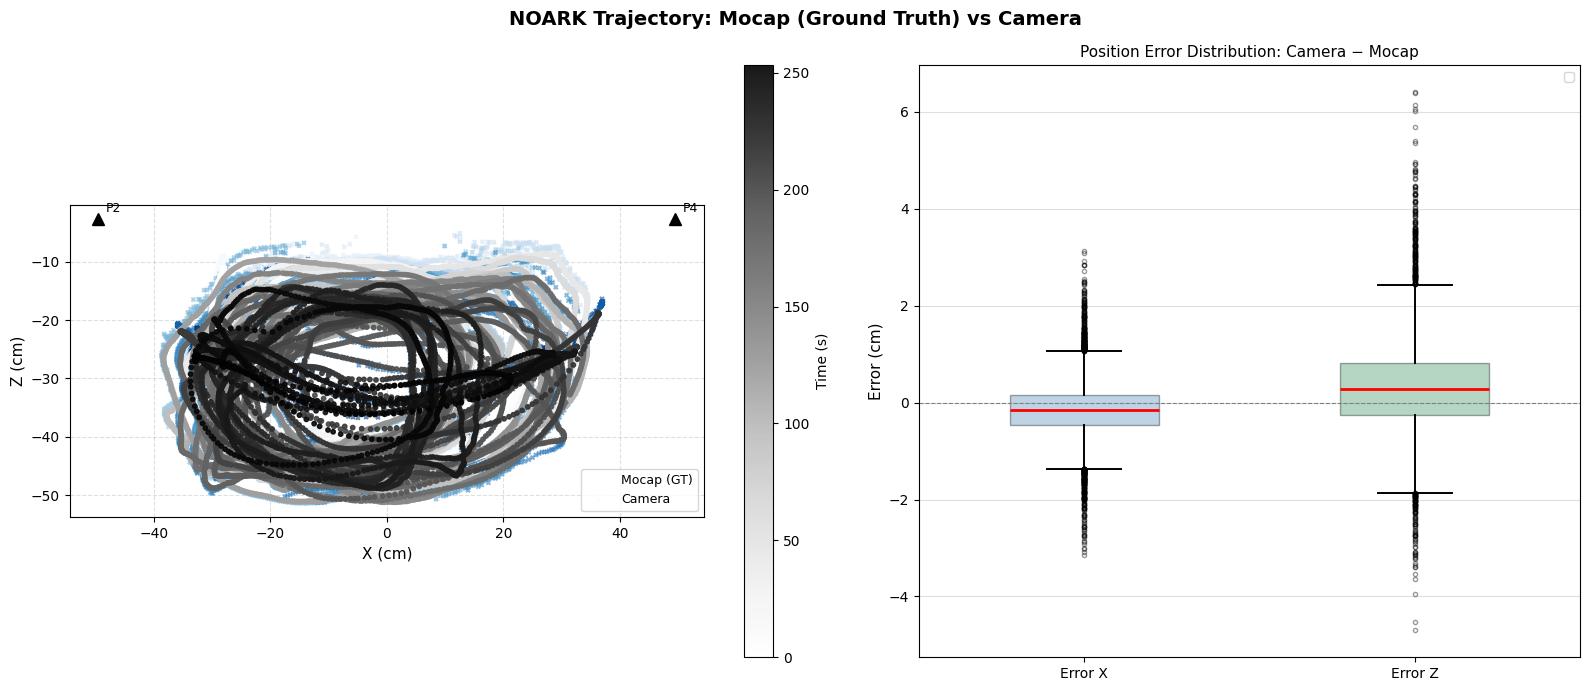

Saved: plot_mocap_vs_camera_2d.png


In [81]:
# Cell 35 — 2D Trajectory + Error Box Plot: Mocap (GT) vs Camera
fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle("NOARK Trajectory: Mocap (Ground Truth) vs Camera", fontsize=14, fontweight='bold')

# ── Left panel: 2D trajectory ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

sc_moc = ax1.scatter(merged['mocap_x'], merged['mocap_z'],
                     c=merged['t_sec'], cmap='Greys', s=10, alpha=0.9,
                     label='Mocap (GT)', zorder=4)
sc_cam = ax1.scatter(merged['x_cam_cm'], merged['z_cam_cm'],
                     c=merged['t_sec'], cmap='Blues', s=8, alpha=0.6,
                     label='Camera', marker='x', zorder=3)

# Pulley reference points from kinematics constants
for name, pt in [('P2', P2), ('P4', P4)]:
    ax1.plot(pt[0]*100, pt[2]*100, 'k^', ms=8, zorder=5)
    ax1.annotate(name, (pt[0]*100, pt[2]*100),
                 textcoords='offset points', xytext=(5, 5), fontsize=9)

plt.colorbar(sc_moc, ax=ax1, label='Time (s)')
ax1.set_xlabel('X (cm)', fontsize=11)
ax1.set_ylabel('Z (cm)', fontsize=11)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_aspect('equal', adjustable='box')

# ── Right panel: Box plot ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])


bp = ax2.boxplot(
    [err_mc_x, err_mc_z],
    labels=['Error X', 'Error Z'],
    patch_artist=True, notch=False, widths=0.45,
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker='o', markersize=3, linestyle='none', alpha=0.4),
)
for patch, color in zip(bp['boxes'], ['steelblue', 'seagreen', 'dimgray']):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)
ax2.axhline(0, color='grey', lw=0.8, ls='--')
ax2.set_ylabel('Error (cm)', fontsize=11)
ax2.set_title('Position Error Distribution: Camera − Mocap', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(repo_root / 'vaideesh' / 'Analysis' / 'plot_mocap_vs_camera_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_mocap_vs_camera_2d.png")

## ERROR STATISTICS — Mocap vs Encoder

In [82]:
# Cell 35
# ── Mocap vs Encoder errors ───────────────────────────────────────────────────
merged['err_me_x_cm']  = merged['x_enc_cm']  - merged['mocap_x']
merged['err_me_z_cm']  = merged['z_enc_cm']  - merged['mocap_z']

mask_me = (~merged['err_me_x_cm'].isna() &
           ~merged['err_me_z_cm'].isna() )

err_me_x   = merged['err_me_x_cm'][mask_me].to_numpy()
err_me_z   = merged['err_me_z_cm'][mask_me].to_numpy()

print(f"Valid frames for Mocap vs Encoder error: {mask_me.sum()} / {len(merged)}")
# arr_stats(err_me_x,  "err_me_x_cm")
# arr_stats(err_me_z,  "err_me_z_cm")

# print(f"Mean absolute error X : {np.mean(np.abs(err_me_x)):.3f} cm")
# print(f"Mean absolute error Z : {np.mean(np.abs(err_me_z)):.3f} cm")
# print(f"Max absolute error X  : {np.max(np.abs(err_me_x)):.3f} cm")
# print(f"Max absolute error Z  : {np.max(np.abs(err_me_z)):.3f} cm")
print_summary_stats(err_me_x, err_me_z, label='Mocap vs Encoder')

Valid frames for Mocap vs Encoder error: 25257 / 25374

────────────────────────────────────────
  Mocap vs Encoder
────────────────────────────────────────
MAE  X              : 1.293 cm
MAE  Z              : 1.687 cm
RMSE X              : 1.820 cm
RMSE Z              : 2.686 cm
Max |err X|         : 11.037 cm
Max |err Z|         : 19.065 cm
Max |err X| @95%    : 3.400 cm
Max |err Z| @95%    : 5.125 cm


In [83]:
# # ── Visualise mocap frozen (dropout) frames ───────────────────────────────────
# mocap_z_diff = merged['z_mocap_cm'].diff().abs()
# mocap_x_diff = merged['x_mocap_cm'].diff().abs()
# dropout_mask = (mocap_z_diff == 0) & (mocap_x_diff == 0)

# print(f"Total frozen frames: {dropout_mask.sum()}")
# print(f"Time window: t = {merged.loc[dropout_mask, 't_sec'].min():.3f}s → {merged.loc[dropout_mask, 't_sec'].max():.3f}s")
# print()
# print("Frozen frames:")
# print(merged.loc[dropout_mask, ['t_sec', 'x_mocap_cm', 'z_mocap_cm',
#                                  'x_enc_cm', 'z_enc_cm',
#                                  'err_me_x_cm', 'err_me_z_cm']].to_string())

Trajectory + Error Box Plot: Mocap (GT) vs Encoder

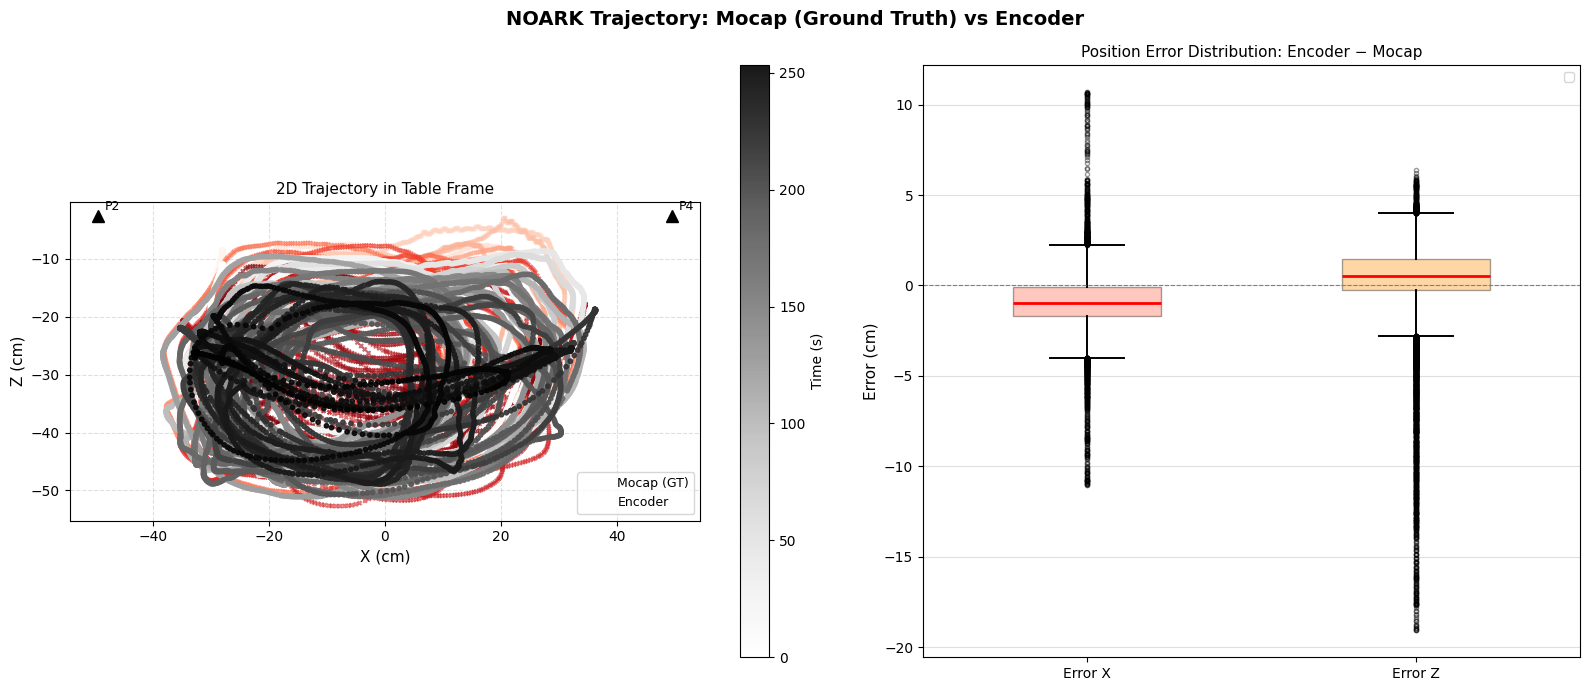

Saved: plot_mocap_vs_encoder_2d.png


In [84]:
# Cell 39 — 2D Trajectory + Error Box Plot: Mocap (GT) vs Encoder
fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle("NOARK Trajectory: Mocap (Ground Truth) vs Encoder", fontsize=14, fontweight='bold')

# ── Left panel: 2D trajectory ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

sc_moc = ax1.scatter(merged['mocap_x'], merged['mocap_z'],
                     c=merged['t_sec'], cmap='Greys', s=10, alpha=0.9,
                     label='Mocap (GT)', zorder=4)
sc_enc = ax1.scatter(merged['x_enc_cm'], merged['z_enc_cm'],
                     c=merged['t_sec'], cmap='Reds', s=8, alpha=0.6,
                     label='Encoder', marker='x', zorder=3)

# Pulley reference points
for name, pt in [('P2', P2), ('P4', P4)]:
    ax1.plot(pt[0]*100, pt[2]*100, 'k^', ms=8, zorder=5)
    ax1.annotate(name, (pt[0]*100, pt[2]*100),
                 textcoords='offset points', xytext=(5, 5), fontsize=9)

plt.colorbar(sc_moc, ax=ax1, label='Time (s)')
ax1.set_xlabel('X (cm)', fontsize=11)
ax1.set_ylabel('Z (cm)', fontsize=11)
ax1.set_title('2D Trajectory in Table Frame', fontsize=11)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_aspect('equal', adjustable='box')

# ── Right panel: Box plot ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])


bp = ax2.boxplot(
    [err_me_x, err_me_z],
    labels=['Error X', 'Error Z'],
    patch_artist=True, notch=False, widths=0.45,
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker='o', markersize=3, linestyle='none', alpha=0.4),
)
for patch, color in zip(bp['boxes'], ['tomato', 'darkorange', 'dimgray']):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

ax2.axhline(0, color='grey', lw=0.8, ls='--')
ax2.set_ylabel('Error (cm)', fontsize=11)
ax2.set_title('Position Error Distribution: Encoder − Mocap', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(repo_root / 'vaideesh' / 'Analysis' / 'plot_mocap_vs_encoder_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_mocap_vs_encoder_2d.png")

## Plot 3: Time-Series — Mocap (GT) vs Camera

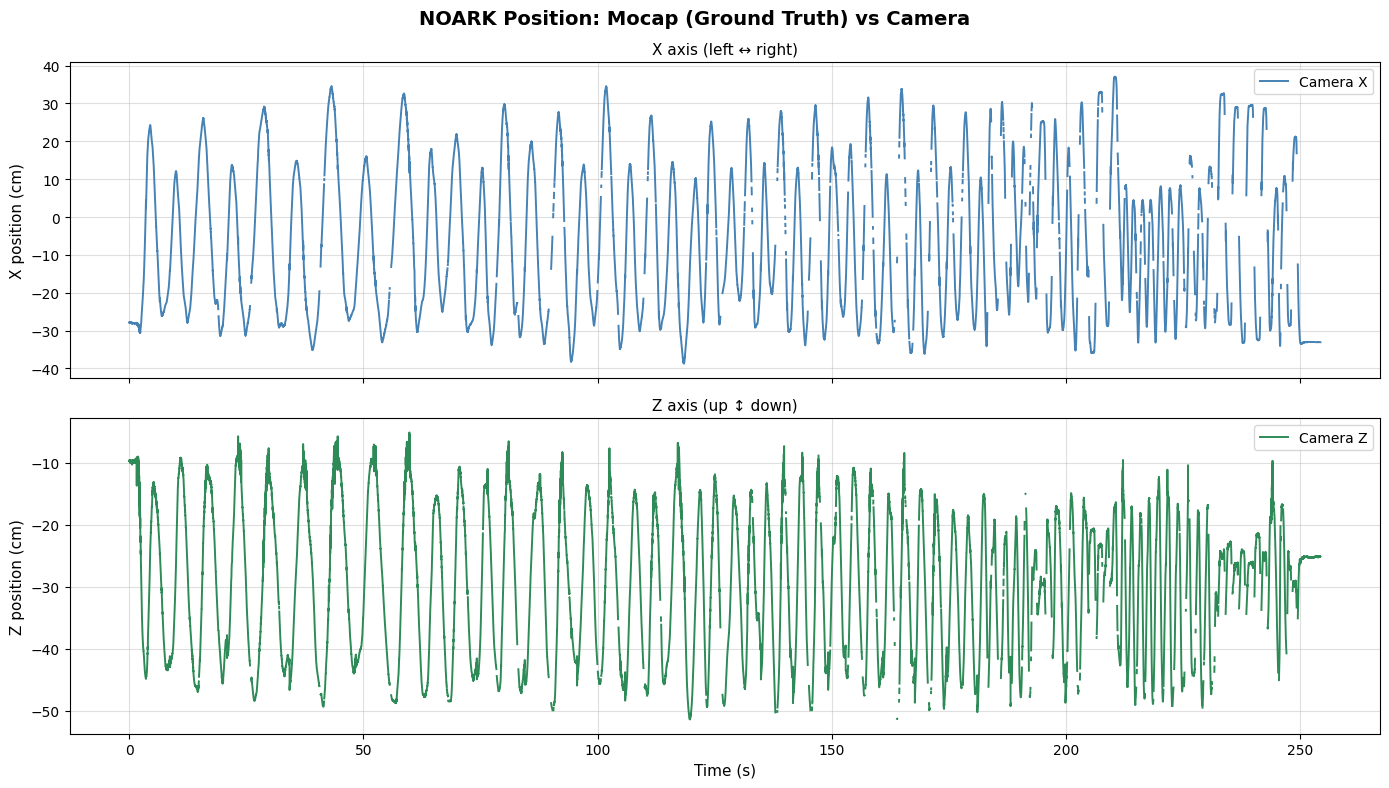

  Camera frame coverage
  Total frames : 25374
  X  valid     : 23645  (93.2%)
  X  missing   : 1729  (6.8%)
  Z  valid     : 23645  (93.2%)
  Z  missing   : 1729  (6.8%)


In [85]:
# Cell 36
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("NOARK Position: Mocap (Ground Truth) vs Camera", fontsize=14, fontweight='bold')

t = merged['t_sec']

ax = axes[0]
# ax.plot(t, merged['mocap_x'], color='black',     lw=2.0, label='Mocap (GT) X')
ax.plot(t, merged['x_cam_cm'],   color='steelblue', lw=1.4, label='Camera X')
# ax.fill_between(t, merged['mocap_x'], merged['x_cam_cm'], alpha=0.15, color='steelblue')
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X axis (left ↔ right)", fontsize=11)

ax = axes[1]
# ax.plot(t, merged['mocap_z'], color='black',    lw=2.0, label='Mocap (GT) Z')
ax.plot(t, merged['z_cam_cm'],   color='seagreen', lw=1.4, label='Camera Z')
# ax.fill_between(t, merged['mocap_z'], merged['z_cam_cm'], alpha=0.15, color='seagreen')
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z axis (up ↕ down)", fontsize=11)

plt.tight_layout()
plt.savefig('plot_mocap_vs_camera_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
total_frames = len(merged)

# X
x_valid = merged['x_cam_cm'].notna().sum()
x_missing = total_frames - x_valid
x_pct_valid = x_valid / total_frames * 100
x_pct_missing = x_missing / total_frames * 100

# Z
z_valid = merged['z_cam_cm'].notna().sum()
z_missing = total_frames - z_valid
z_pct_valid = z_valid / total_frames * 100
z_pct_missing = z_missing / total_frames * 100

print(f"{'':=<45}")
print(f"  Camera frame coverage")
print(f"{'':=<45}")
print(f"  Total frames : {total_frames}")
print(f"  X  valid     : {x_valid}  ({x_pct_valid:.1f}%)")
print(f"  X  missing   : {x_missing}  ({x_pct_missing:.1f}%)")
print(f"  Z  valid     : {z_valid}  ({z_pct_valid:.1f}%)")
print(f"  Z  missing   : {z_missing}  ({z_pct_missing:.1f}%)")
print(f"{'':=<45}")

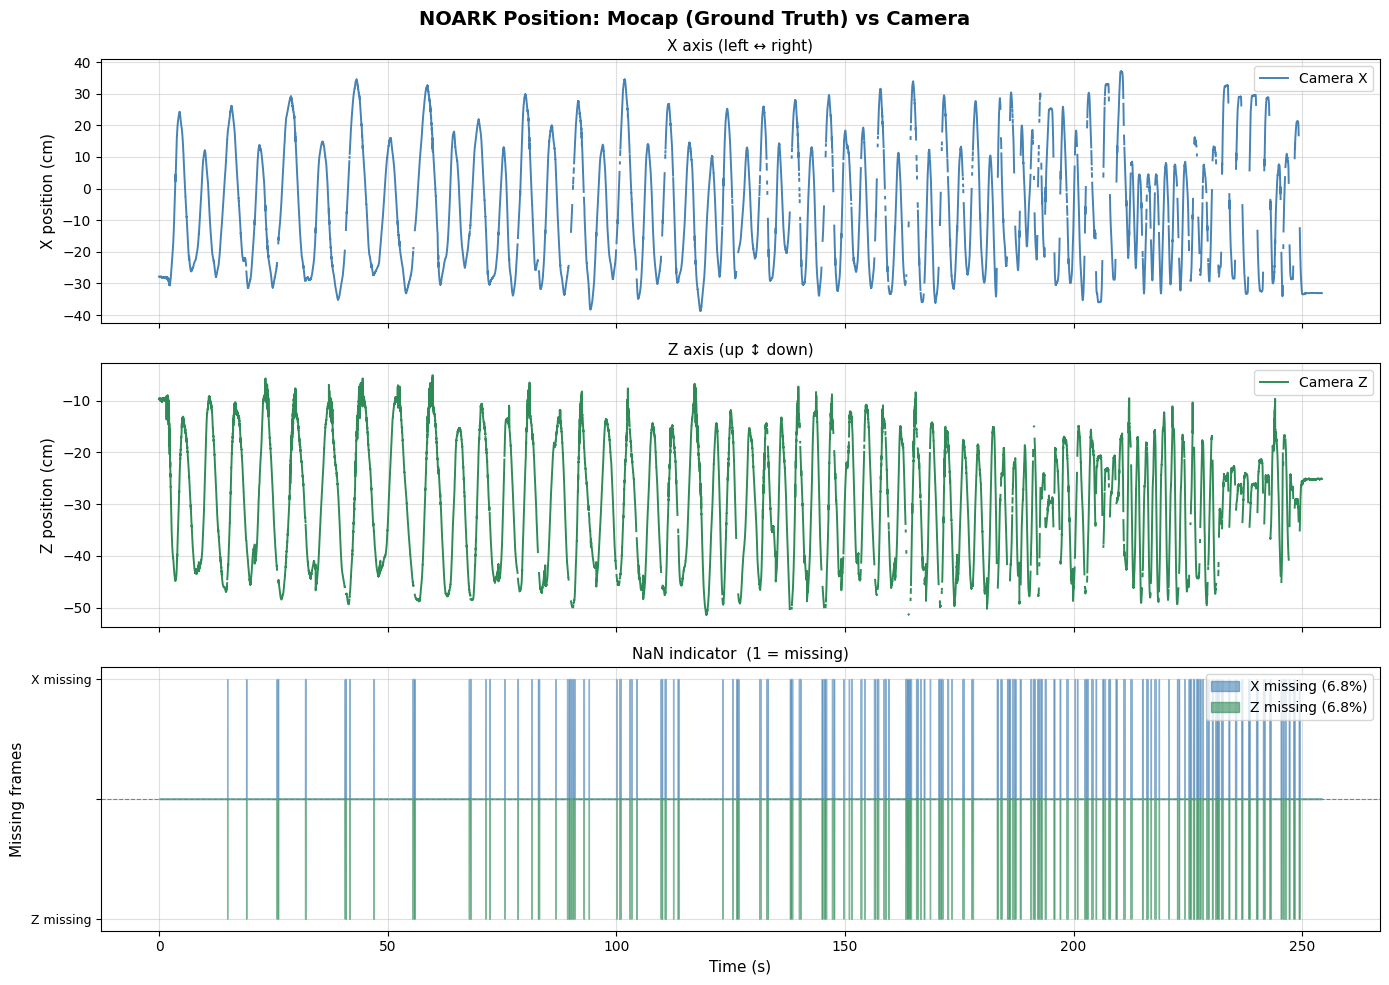

  Camera frame coverage
  Total frames : 25374
  X  valid     : 23645  (93.2%)
  X  missing   : 1729  (6.8%)
  Z  valid     : 23645  (93.2%)
  Z  missing   : 1729  (6.8%)


In [86]:
# Cell 36
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("NOARK Position: Mocap (Ground Truth) vs Camera", fontsize=14, fontweight='bold')

t = merged['t_sec']

# ── X position ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(t, merged['x_cam_cm'], color='steelblue', lw=1.4, label='Camera X')
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X axis (left ↔ right)", fontsize=11)

# ── Z position ────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(t, merged['z_cam_cm'], color='seagreen', lw=1.4, label='Camera Z')
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z axis (up ↕ down)", fontsize=11)

# ── NaN indicator panel ───────────────────────────────────────────────────────
total_frames  = len(merged)
x_nan_flag    = merged['x_cam_cm'].isna().astype(int)   # 1 where X is missing
z_nan_flag    = merged['z_cam_cm'].isna().astype(int)   # 1 where Z is missing

x_missing     = x_nan_flag.sum()
z_missing     = z_nan_flag.sum()
x_pct_missing = x_missing / total_frames * 100
z_pct_missing = z_missing / total_frames * 100

ax = axes[2]
ax.fill_between(t, x_nan_flag,         color='steelblue', alpha=0.6,
                label=f'X missing ({x_pct_missing:.1f}%)')
ax.fill_between(t, z_nan_flag * -1,    color='seagreen',  alpha=0.6,
                label=f'Z missing ({z_pct_missing:.1f}%)')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Z missing', '', 'X missing'], fontsize=9)
ax.set_ylabel("Missing frames", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("NaN indicator  (1 = missing)", fontsize=11)

plt.tight_layout()
plt.savefig('plot_mocap_vs_camera_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Console summary ───────────────────────────────────────────────────────────
x_valid     = total_frames - x_missing
z_valid     = total_frames - z_missing

print(f"{'':=<45}")
print(f"  Camera frame coverage")
print(f"{'':=<45}")
print(f"  Total frames : {total_frames}")
print(f"  X  valid     : {x_valid}  ({100 - x_pct_missing:.1f}%)")
print(f"  X  missing   : {x_missing}  ({x_pct_missing:.1f}%)")
print(f"  Z  valid     : {z_valid}  ({100 - z_pct_missing:.1f}%)")
print(f"  Z  missing   : {z_missing}  ({z_pct_missing:.1f}%)")
print(f"{'':=<45}")

In [87]:
# ── Max consecutive missing duration ─────────────────────────────────────────
def max_missing_duration(series, t_series):
    """Find max consecutive NaN duration in seconds."""
    is_nan   = series.isna().values
    t_vals   = t_series.values
    
    max_dur  = 0.0
    max_start = None
    max_end   = None
    
    in_gap    = False
    gap_start = None
    
    for i in range(len(is_nan)):
        if is_nan[i] and not in_gap:
            in_gap    = True
            gap_start = t_vals[i]
        elif not is_nan[i] and in_gap:
            in_gap   = False
            gap_dur  = t_vals[i] - gap_start
            if gap_dur > max_dur:
                max_dur   = gap_dur
                max_start = gap_start
                max_end   = t_vals[i]
    
    # Handle gap that extends to end
    if in_gap:
        gap_dur = t_vals[-1] - gap_start
        if gap_dur > max_dur:
            max_dur   = gap_dur
            max_start = gap_start
            max_end   = t_vals[-1]
    
    return max_dur, max_start, max_end

def gap_stats(series, t_series):
    """All gap durations."""
    is_nan  = series.isna().values
    t_vals  = t_series.values
    gaps    = []
    in_gap  = False
    g_start = None
    
    for i in range(len(is_nan)):
        if is_nan[i] and not in_gap:
            in_gap  = True
            g_start = t_vals[i]
        elif not is_nan[i] and in_gap:
            in_gap = False
            gaps.append(t_vals[i] - g_start)
    if in_gap:
        gaps.append(t_vals[-1] - g_start)
    
    return np.array(gaps)

x_gaps = gap_stats(merged['x_cam_cm'], merged['t_sec'])
z_gaps = gap_stats(merged['z_cam_cm'], merged['t_sec'])

x_max_dur, x_max_start, x_max_end = max_missing_duration(merged['x_cam_cm'], merged['t_sec'])
z_max_dur, z_max_start, z_max_end = max_missing_duration(merged['z_cam_cm'], merged['t_sec'])

print(f"{'':=<55}")
print(f"  Camera frame coverage")
print(f"{'':=<55}")
print(f"  Total frames          : {total_frames}")
print(f"  X  valid              : {x_valid}  ({100 - x_pct_missing:.1f}%)")
print(f"  X  missing            : {x_missing}  ({x_pct_missing:.1f}%)")
print(f"  X  total gaps         : {len(x_gaps)}")
print(f"  X  max gap duration   : {x_max_dur:.3f} s  (t={x_max_start:.3f} → {x_max_end:.3f} s)")
print(f"{'':->55}")
print(f"  Z  valid              : {z_valid}  ({100 - z_pct_missing:.1f}%)")
print(f"  Z  missing            : {z_missing}  ({z_pct_missing:.1f}%)")
print(f"  Z  total gaps         : {len(z_gaps)}")
print(f"  Z  max gap duration   : {z_max_dur:.3f} s  (t={z_max_start:.3f} → {z_max_end:.3f} s)")
print(f"{'':=<55}")

  Camera frame coverage
  Total frames          : 25374
  X  valid              : 23645  (93.2%)
  X  missing            : 1729  (6.8%)
  X  total gaps         : 333
  X  max gap duration   : 0.593 s  (t=185.455 → 186.048 s)
-------------------------------------------------------
  Z  valid              : 23645  (93.2%)
  Z  missing            : 1729  (6.8%)
  Z  total gaps         : 333
  Z  max gap duration   : 0.593 s  (t=185.455 → 186.048 s)


In [88]:
# ── Independent verification of every stat ───────────────────────────────────
print("=== VERIFICATION ===\n")

# 1. Total frames
print(f"1. Total frames = len(merged) = {len(merged)}")

# 2. X/Z valid — count notna directly
x_notna = merged['x_cam_cm'].notna().sum()
z_notna = merged['z_cam_cm'].notna().sum()
print(f"2. X valid (notna)  = {x_notna}")
print(f"   Z valid (notna)  = {z_notna}")
print(f"   X == Z ?         = {x_notna == z_notna}  ← must be True")

# 3. Missing = total - valid
print(f"3. X missing = {len(merged)} - {x_notna} = {len(merged) - x_notna}")
print(f"   Z missing = {len(merged)} - {z_notna} = {len(merged) - z_notna}")

# 4. Percentage
print(f"4. X missing % = {(len(merged)-x_notna)/len(merged)*100:.2f}%")

# 5. Gap count — count transitions from valid to NaN
x_nan = merged['x_cam_cm'].isna()
transitions_to_nan = ((~x_nan.shift(1).fillna(False)) & x_nan).sum()
print(f"5. X gap count (transitions valid→NaN) = {transitions_to_nan}")

# 6. Max gap — find it manually
gaps = []
in_gap = False
g_start_t = None
g_start_i = None
for i, (is_nan, t_val) in enumerate(zip(x_nan, merged['t_sec'])):
    if is_nan and not in_gap:
        in_gap    = True
        g_start_t = t_val
        g_start_i = i
    elif not is_nan and in_gap:
        in_gap = False
        gaps.append((t_val - g_start_t, g_start_t, t_val, g_start_i, i))

gaps_sorted = sorted(gaps, reverse=True)
print(f"6. Top 5 largest gaps:")
for dur, t0, t1, i0, i1 in gaps_sorted[:5]:
    print(f"   {dur:.3f}s  (t={t0:.3f} → {t1:.3f})  rows {i0}→{i1}  ({i1-i0} frames)")

# 7. Spot check the max gap region
max_gap = gaps_sorted[0]
i0, i1 = max_gap[3], max_gap[4]
print(f"\n7. Spot check max gap rows {i0-2} → {i1+2}:")
print(merged[['t_sec','x_cam_cm','z_cam_cm']].iloc[i0-2:i1+3].to_string())

# 8. Pre/post sync split
pre  = (merged['t_sec'] < 0).sum()
post = (merged['t_sec'] >= 0).sum()
post_missing = merged.loc[merged['t_sec'] >= 0, 'x_cam_cm'].isna().sum()
print(f"\n8. Pre-sync frames (t<0)     : {pre}")
print(f"   Post-sync frames (t>=0)   : {post}")
print(f"   Post-sync missing         : {post_missing}  ({100*post_missing/post:.2f}%)")
print(f"   Post-sync detection rate  : {100*(post-post_missing)/post:.2f}%")

=== VERIFICATION ===

1. Total frames = len(merged) = 25374
2. X valid (notna)  = 23645
   Z valid (notna)  = 23645
   X == Z ?         = True  ← must be True
3. X missing = 25374 - 23645 = 1729
   Z missing = 25374 - 23645 = 1729
4. X missing % = 6.81%
5. X gap count (transitions valid→NaN) = 333
6. Top 5 largest gaps:
   0.593s  (t=185.455 → 186.048)  rows 18498→18557  (59 frames)
   0.491s  (t=89.591 → 90.082)  rows 8934→8983  (49 frames)
   0.417s  (t=163.492 → 163.910)  rows 16310→16350  (40 frames)
   0.411s  (t=231.210 → 231.620)  rows 23066→23107  (41 frames)
   0.380s  (t=137.937 → 138.317)  rows 13755→13793  (38 frames)

7. Spot check max gap rows 18496 → 18559:
            t_sec   x_cam_cm   z_cam_cm
18496  185.434288 -22.064462 -41.270949
18497  185.444136 -21.791516 -41.616818
18498  185.455308        NaN        NaN
18499  185.467000        NaN        NaN
18500  185.473673        NaN        NaN
18501  185.484164        NaN        NaN
18502  185.494134        NaN        NaN

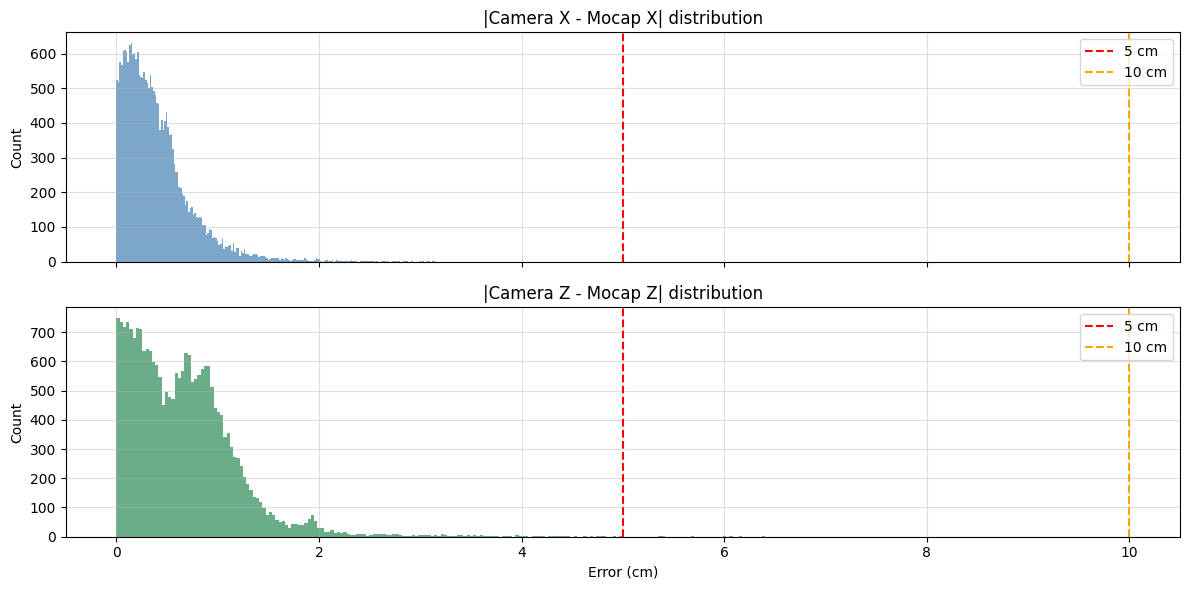

Percentile     err_x (cm)   err_z (cm)
--------------------------------------
95                  1.019        1.542


In [89]:
# Both camera and mocap must be valid
both_valid = (
    merged['x_cam_cm'].notna() & 
    merged['z_cam_cm'].notna() &
    merged['mocap_x'].notna() & 
    merged['mocap_z'].notna()
)

err_x = (merged['x_cam_cm'] - merged['mocap_x']).abs()
err_z = (merged['z_cam_cm'] - merged['mocap_z']).abs()

# Plot error distribution to find natural threshold
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].hist(err_x[both_valid], bins=200, color='steelblue', alpha=0.7)
axes[0].set_title('|Camera X - Mocap X| distribution')
axes[0].set_ylabel('Count')
axes[0].axvline(5, color='red', ls='--', label='5 cm')
axes[0].axvline(10, color='orange', ls='--', label='10 cm')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].hist(err_z[both_valid], bins=200, color='seagreen', alpha=0.7)
axes[1].set_title('|Camera Z - Mocap Z| distribution')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Error (cm)')
axes[1].axvline(5, color='red', ls='--', label='5 cm')
axes[1].axvline(10, color='orange', ls='--', label='10 cm')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Print percentile breakdown
print(f"{'Percentile':<12} {'err_x (cm)':>12} {'err_z (cm)':>12}")
print("-" * 38)
for p in [95]:
    ex = np.nanpercentile(err_x[both_valid], p)
    ez = np.nanpercentile(err_z[both_valid], p)
    print(f"{p:<12} {ex:>12.3f} {ez:>12.3f}")

In [90]:
# # Cell 36 — NOARK Position: Mocap (Ground Truth) vs Camera  [FIXED]

# import matplotlib.pyplot as plt
# import numpy as np

# # ── Guard ─────────────────────────────────────────────────────────────────────
# _required = ['x_cam_cm', 'z_cam_cm', 'mocap_x', 'mocap_z', 't_sec']
# assert 'merged' in dir(), "❌ Run Cell 27 first — `merged` not defined."
# missing = [c for c in _required if c not in merged.columns]
# assert not missing, f"❌ merged missing columns: {missing} — run Cells 27–28."

# fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
# fig.suptitle("NOARK Position: Mocap (Ground Truth) vs Camera",
#              fontsize=14, fontweight='bold')

# t = merged['t_sec']

# # ── FIX B4: plot BOTH mocap and camera on each position panel ─────────────────

# # X position
# # axes[0].plot(t, merged['mocap_x'], color='black',     lw=1.6, label='Mocap X (ground truth)')
# axes[0].plot(t, merged['x_cam_cm'],   color='steelblue', lw=1.2, ls='--', label='Camera X')
# axes[0].set_ylabel("X position (cm)", fontsize=11)
# axes[0].legend(loc='upper right', fontsize=10)
# axes[0].grid(True, alpha=0.4)
# axes[0].set_title("X axis (left ↔ right)", fontsize=11)

# # Z position
# # axes[1].plot(t, merged['mocap_z'], color='black',    lw=1.6, label='Mocap Z (ground truth)')
# axes[1].plot(t, merged['z_cam_cm'],   color='seagreen', lw=1.2, ls='--', label='Camera Z')
# axes[1].set_ylabel("Z position (cm)", fontsize=11)
# axes[1].legend(loc='upper right', fontsize=10)
# axes[1].grid(True, alpha=0.4)
# axes[1].set_title("Z axis (up ↕ down)", fontsize=11)

# # ── NaN indicator panel ───────────────────────────────────────────────────────
# total_frames = len(merged)

# # FIX B2: use a combined "any missing" flag rather than two identical flags
# cam_nan_flag = (merged['x_cam_cm'].isna() | merged['z_cam_cm'].isna()).astype(int)
# n_missing    = cam_nan_flag.sum()
# pct_missing  = n_missing / total_frames * 100

# # FIX B3: no more z_nan_flag * -1 — show one clear missing-frame indicator
# ax_nan = axes[2]
# ax_nan.fill_between(t, cam_nan_flag, color='tomato', alpha=0.6,
#                     label=f'Camera XZ missing ({pct_missing:.1f}%)')
# ax_nan.axhline(0, color='gray', lw=0.8, ls='--')
# ax_nan.set_yticks([0, 1])
# ax_nan.set_yticklabels(['present', 'missing'], fontsize=9)
# ax_nan.set_ylabel("Camera frames", fontsize=11)
# ax_nan.set_xlabel("Time (s)", fontsize=11)
# ax_nan.legend(loc='upper right', fontsize=10)
# ax_nan.grid(True, alpha=0.4)
# ax_nan.set_title("Missing camera frames (1 = no detection)", fontsize=11)

# # FIX B6: annotate the % directly on the NaN panel
# ax_nan.annotate(
#     f"{pct_missing:.1f}% missing ({n_missing}/{total_frames} frames)",
#     xy=(0.01, 0.85), xycoords='axes fraction',
#     fontsize=9, color='tomato', fontweight='bold'
# )

# plt.tight_layout()
# plt.savefig('plot_mocap_vs_camera_timeseries.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ── Console summary ───────────────────────────────────────────────────────────
# n_valid = total_frames - n_missing
# print(f"{'':=<45}")
# print(f"  Camera frame coverage")
# print(f"{'':=<45}")
# print(f"  Total frames : {total_frames}")
# print(f"  Valid        : {n_valid}  ({100 - pct_missing:.1f}%)")
# print(f"  Missing      : {n_missing}  ({pct_missing:.1f}%)")
# print(f"{'':=<45}")

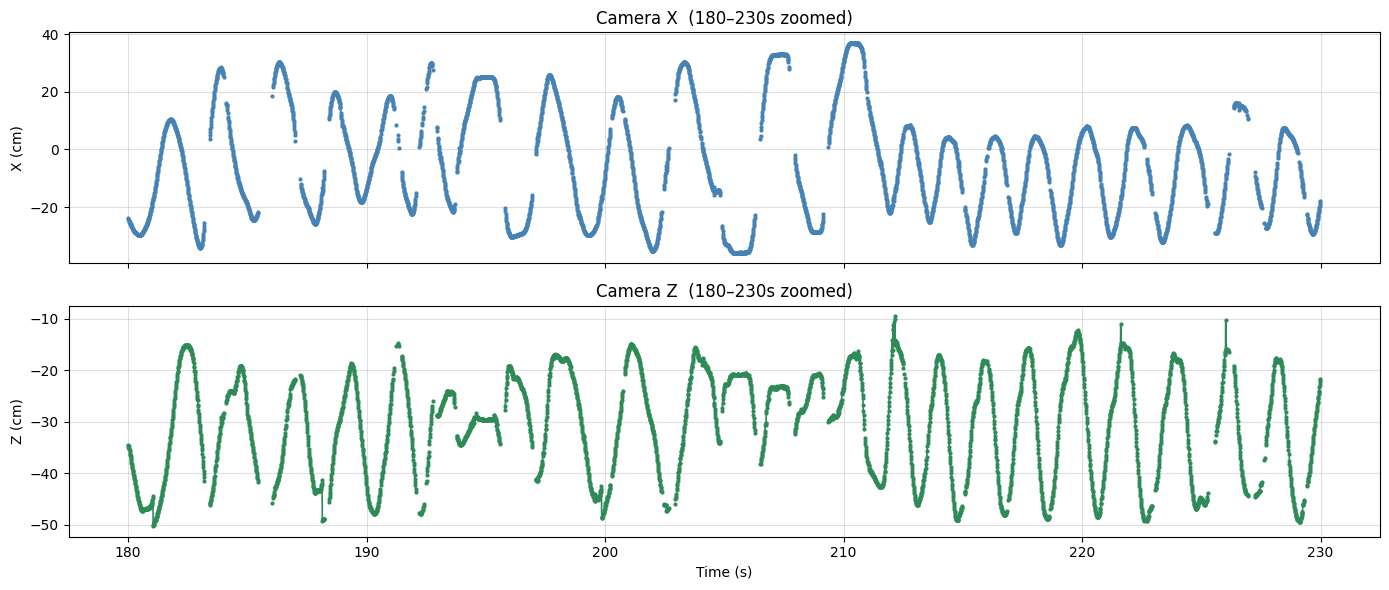

In [91]:
# Zoom into a known gap region to confirm Z also has gaps
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Pick a 10s window where you can see X gaps clearly
t_start, t_end = 180, 230

mask = (merged['t_sec'] >= t_start) & (merged['t_sec'] <= t_end)
t_zoom = merged.loc[mask, 't_sec']

axes[0].plot(t_zoom, merged.loc[mask, 'x_cam_cm'], color='steelblue', lw=1.2, marker='o', ms=2)
axes[0].set_title(f'Camera X  ({t_start}–{t_end}s zoomed)')
axes[0].set_ylabel('X (cm)')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t_zoom, merged.loc[mask, 'z_cam_cm'], color='seagreen', lw=1.2, marker='o', ms=2)
axes[1].set_title(f'Camera Z  ({t_start}–{t_end}s zoomed)')
axes[1].set_ylabel('Z (cm)')
axes[1].grid(True, alpha=0.4)

axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

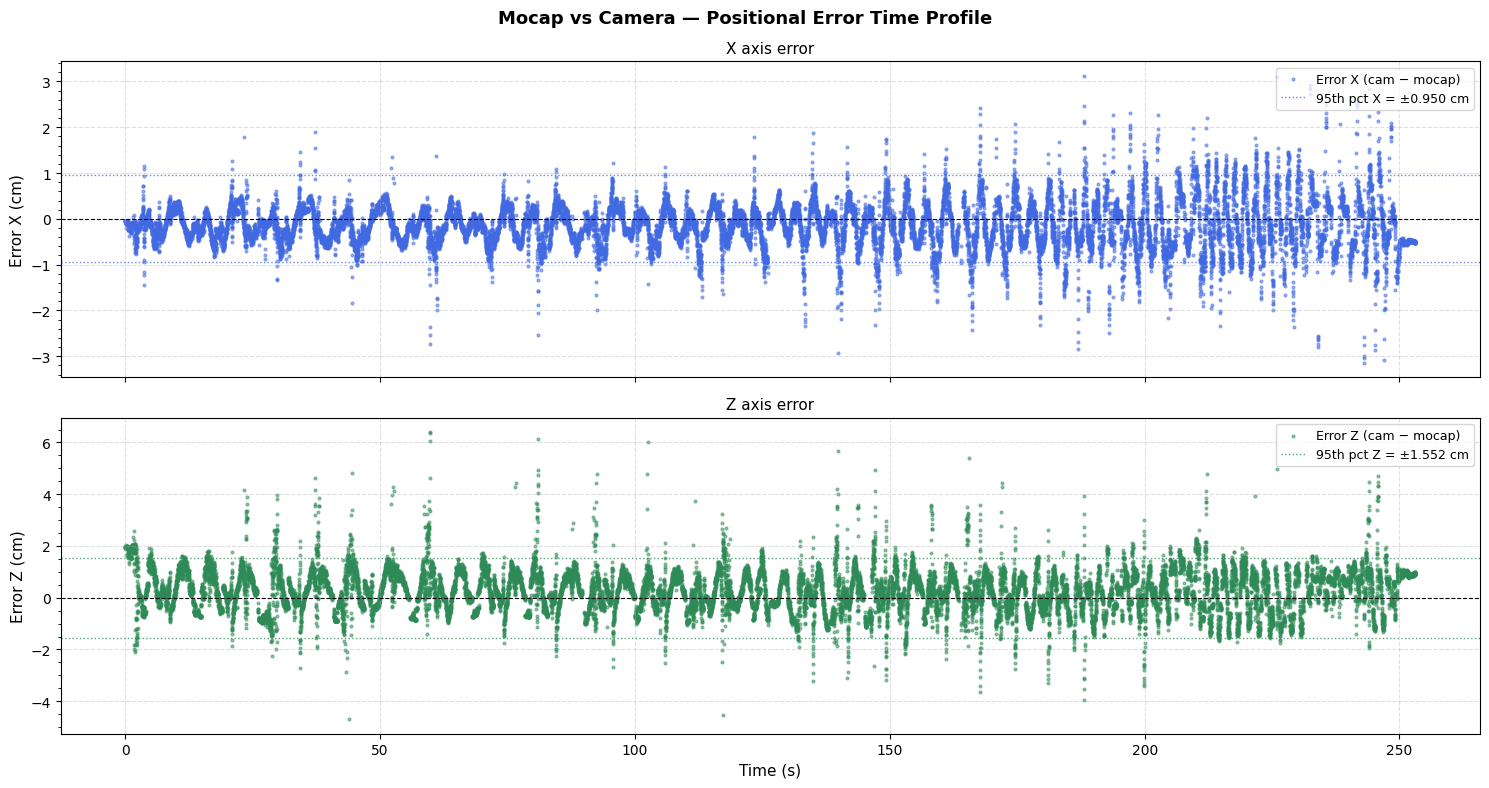

In [92]:
# ── Error time profile: Mocap vs Camera ──────────────────────────────────────
t_mc = merged['t_sec'][mask_mc].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle("Mocap vs Camera — Positional Error Time Profile", fontsize=13, fontweight='bold')

# ── X error ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(t_mc, err_mc_x, color='royalblue', s=4, alpha=0.5, label='Error X (cam − mocap)')
ax.axhline(0,      color='black',     lw=0.8, ls='--')
ax.axhline( 0.950, color='royalblue', lw=1.0, ls=':', alpha=0.8, label='95th pct X = ±0.950 cm')
ax.axhline(-0.950, color='royalblue', lw=1.0, ls=':', alpha=0.8)
ax.set_ylabel('Error X (cm)', fontsize=11)
ax.set_title('X axis error', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# ── Z error ──────────────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(t_mc, err_mc_z, color='seagreen', s=4, alpha=0.5, label='Error Z (cam − mocap)')
ax.axhline(0,      color='black',    lw=0.8, ls='--')
ax.axhline( 1.552, color='seagreen', lw=1.0, ls=':', alpha=0.8, label='95th pct Z = ±1.552 cm')
ax.axhline(-1.552, color='seagreen', lw=1.0, ls=':', alpha=0.8)
ax.set_ylabel('Error Z (cm)', fontsize=11)
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_title('Z axis error', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig('mocap_vs_camera_error_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4: Time-Series — Mocap (GT) vs Encoder

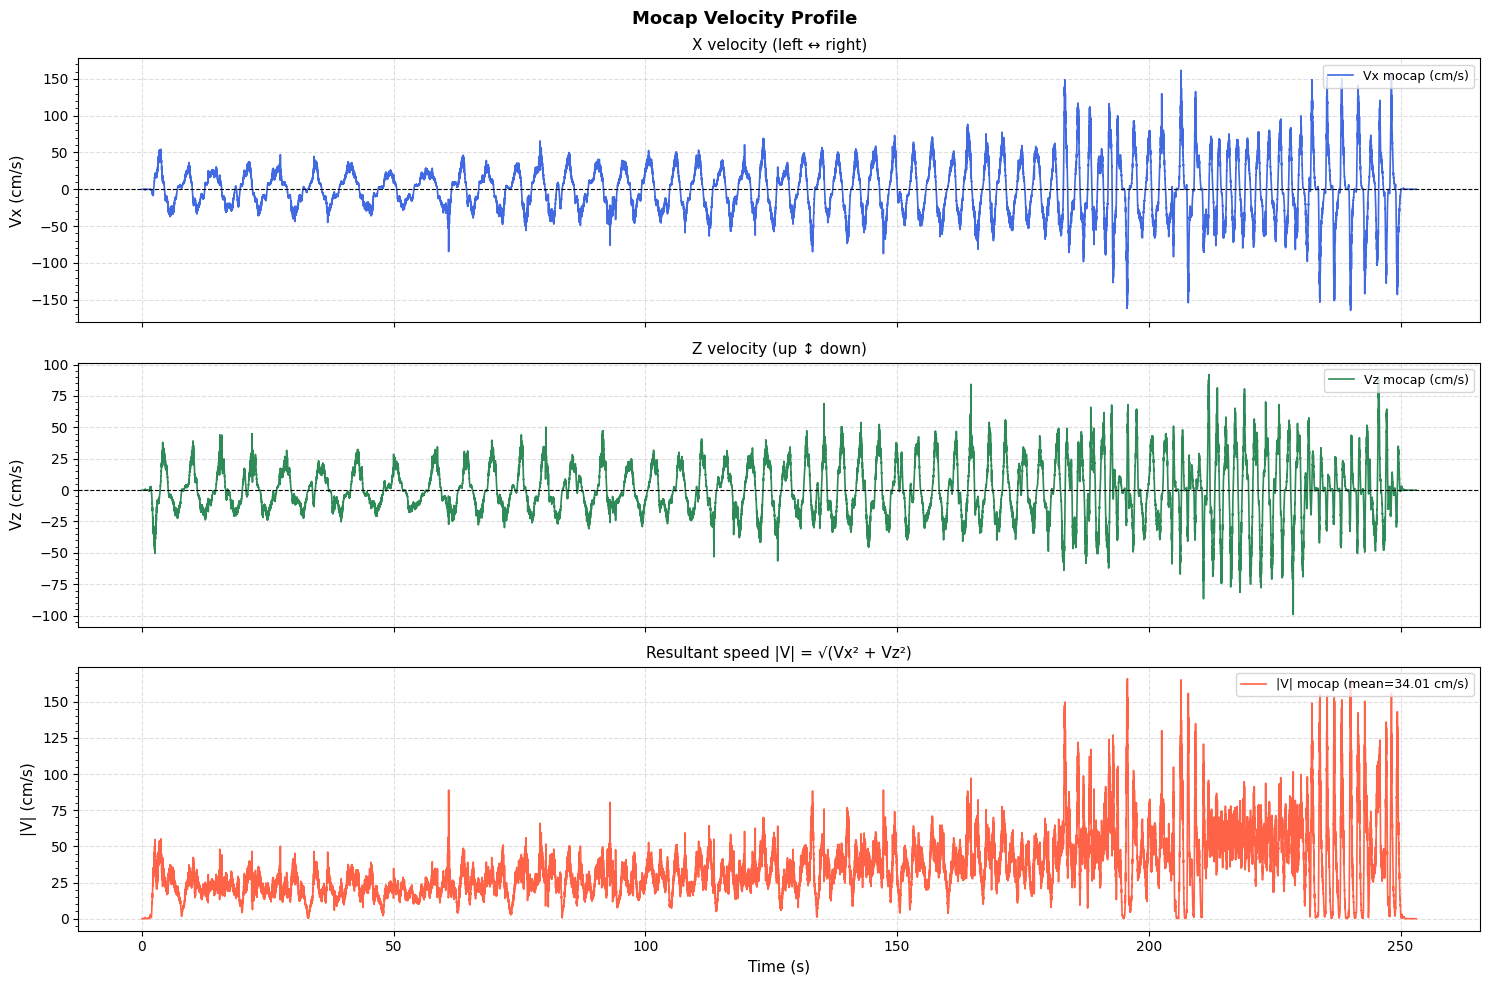


=== Mocap Velocity Stats ===
Vx  mean=-0.018  std=34.457  min=-164.531  max=161.601 cm/s
Vz  mean=-0.045  std=20.915  min=-99.114  max=92.072 cm/s
|V| mean=34.011  std=21.633  min=0.001  max=165.916 cm/s

=== Mean Resultant Speed ===
  Mocap   : 34.011 cm/s  (std: 21.633)
  Encoder : 33.586 cm/s  (std: 19.952)
  Error (Enc - Mocap): -0.271 cm/s


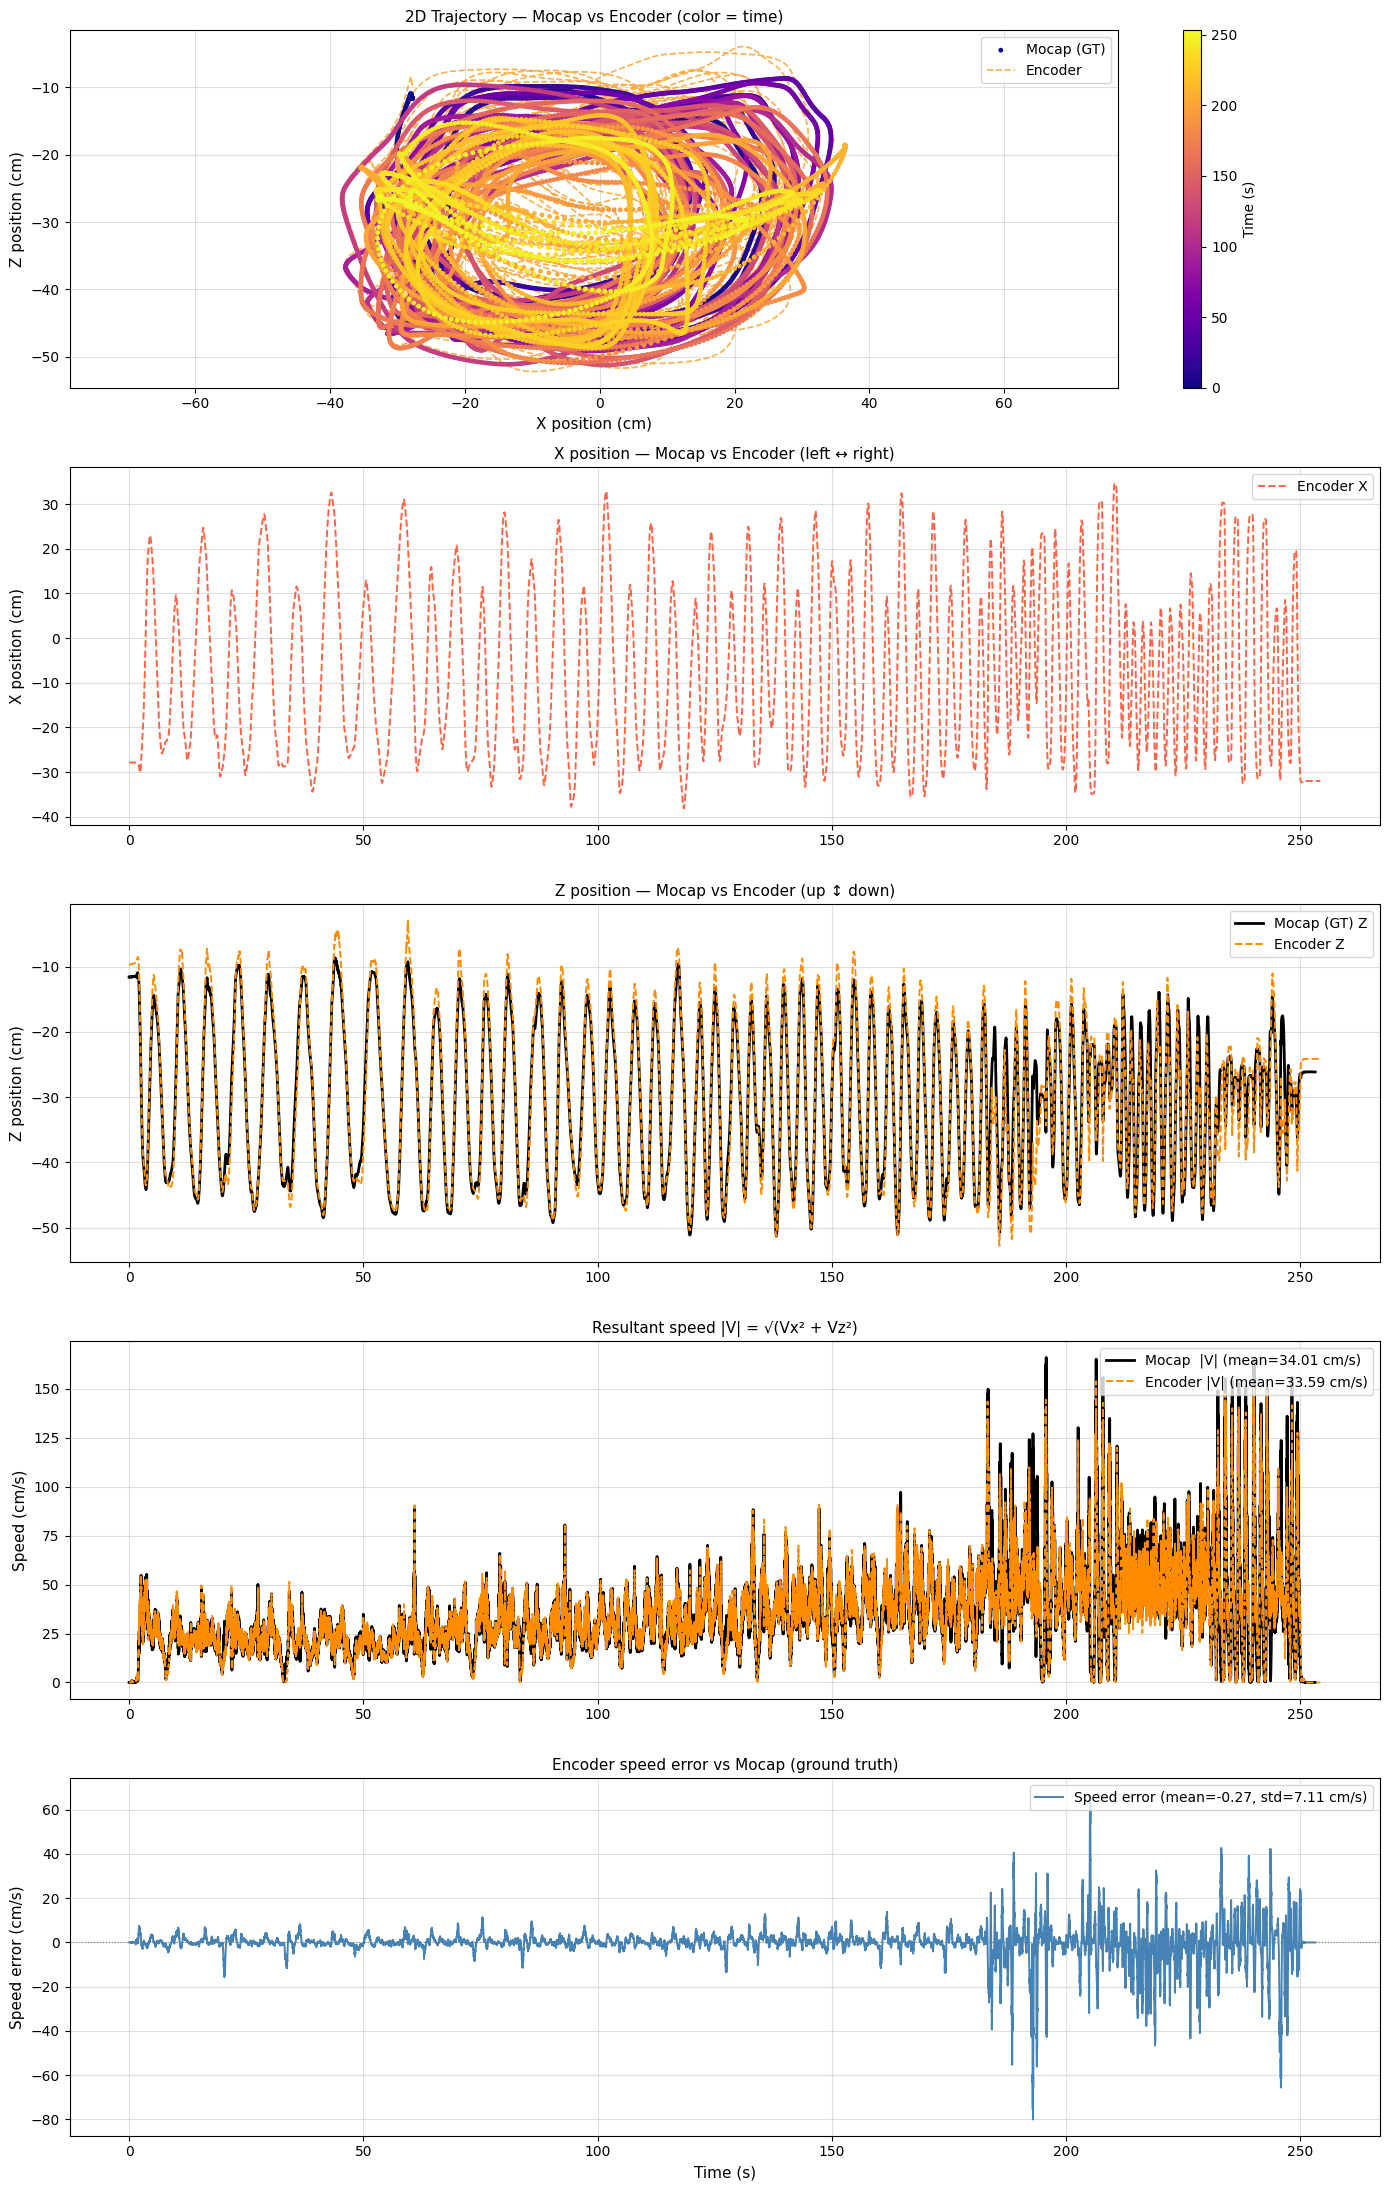

In [93]:
## Cell 38 — 5-panel: Trajectory + Position + Speed
from scipy.signal import savgol_filter
import numpy as np
import matplotlib.ticker as ticker

# ── Step 0: Clean — only remove inf, keep ALL NaNs intact ────────────────────
all_cols = ['x_enc_cm', 'z_enc_cm', 'mocap_x', 'mocap_z']

merged_clean = merged.copy()
for col in all_cols:
    merged_clean[col] = merged_clean[col].replace([np.inf, -np.inf], np.nan)

# Save dropout masks BEFORE any smoothing
valid_mocap = merged_clean['mocap_x'].notna().values
valid_enc   = merged_clean['x_enc_cm'].notna().values

t = merged_clean['t_sec'].values
n = len(merged_clean)

# ── Step 1: Smooth — per segment, no filling ─────────────────────────────────
window = 51
poly   = 3

def safe_savgol_no_fill(x, window, poly):
    """
    Savgol per contiguous valid segment only.
    No filling across gaps — NaN regions stay NaN completely.
    """
    if isinstance(x, pd.Series):
        x = x.values
    x = x.astype(float)
    result = np.full_like(x, np.nan, dtype=float)
    valid  = ~np.isnan(x)
    idx    = np.where(valid)[0]
    if len(idx) == 0:
        return result
    breaks   = np.where(np.diff(idx) > 1)[0] + 1
    segments = np.split(idx, breaks)
    for seg in segments:
        seg_len = len(seg)
        if seg_len < poly + 1:
            result[seg] = x[seg]   # too short to smooth — copy raw
            continue
        w = min(window, seg_len if seg_len % 2 == 1 else seg_len - 1)
        result[seg] = savgol_filter(x[seg], w, poly)
    return result

x_mocap_s = safe_savgol_no_fill(merged_clean['mocap_x'].values, window, poly)
z_mocap_s = safe_savgol_no_fill(merged_clean['mocap_z'].values, window, poly)
x_enc_s   = safe_savgol_no_fill(merged_clean['x_enc_cm'].values,   window, poly)
z_enc_s   = safe_savgol_no_fill(merged_clean['z_enc_cm'].values,   window, poly)

# ── Step 2: Velocity — central differences, no boundary artifacts ─────────────
def velocity_from_position(x, t):
    """
    Central difference on interior points of each contiguous valid segment.
    First and last point of every segment left as NaN — no edge artifacts.
    """
    result = np.full_like(x, np.nan, dtype=float)
    valid  = ~np.isnan(x)
    idx    = np.where(valid)[0]
    if len(idx) < 3:
        return result
    breaks   = np.where(np.diff(idx) > 1)[0] + 1
    segments = np.split(idx, breaks)
    for seg in segments:
        if len(seg) < 3:
            continue
        interior         = seg[1:-1]
        prev             = seg[:-2]
        nxt              = seg[2:]
        dx               = x[nxt] - x[prev]
        dt               = t[nxt] - t[prev]
        result[interior] = dx / dt
    return result

vx_mocap = velocity_from_position(x_mocap_s, t)
vz_mocap = velocity_from_position(z_mocap_s, t)
vx_enc   = velocity_from_position(x_enc_s,   t)
vz_enc   = velocity_from_position(z_enc_s,   t)

# Null out original dropout regions
vx_mocap[~valid_mocap] = np.nan
vz_mocap[~valid_mocap] = np.nan
vx_enc[~valid_enc]     = np.nan
vz_enc[~valid_enc]     = np.nan

speed_mocap = np.sqrt(vx_mocap**2 + vz_mocap**2)
speed_enc   = np.sqrt(vx_enc**2   + vz_enc**2)
speed_err   = speed_enc - speed_mocap

# ── Step 2b: Velocity profile plot ───────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
fig.suptitle("Mocap Velocity Profile", fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(t, vx_mocap, color='royalblue', lw=1.2, label='Vx mocap (cm/s)')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('Vx (cm/s)', fontsize=11)
ax.set_title('X velocity (left ↔ right)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax = axes[1]
ax.plot(t, vz_mocap, color='seagreen', lw=1.2, label='Vz mocap (cm/s)')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('Vz (cm/s)', fontsize=11)
ax.set_title('Z velocity (up ↕ down)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax = axes[2]
ax.plot(t, speed_mocap, color='tomato', lw=1.2,
        label=f'|V| mocap (mean={np.nanmean(speed_mocap):.2f} cm/s)')
ax.set_ylabel('|V| (cm/s)', fontsize=11)
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_title('Resultant speed |V| = √(Vx² + Vz²)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig('mocap_velocity_profile.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Step 3: Stats ─────────────────────────────────────────────────────────────
print(f"\n=== Mocap Velocity Stats ===")
print(f"Vx  mean={np.nanmean(vx_mocap):+.3f}  std={np.nanstd(vx_mocap):.3f}  min={np.nanmin(vx_mocap):.3f}  max={np.nanmax(vx_mocap):.3f} cm/s")
print(f"Vz  mean={np.nanmean(vz_mocap):+.3f}  std={np.nanstd(vz_mocap):.3f}  min={np.nanmin(vz_mocap):.3f}  max={np.nanmax(vz_mocap):.3f} cm/s")
print(f"|V| mean={np.nanmean(speed_mocap):.3f}  std={np.nanstd(speed_mocap):.3f}  min={np.nanmin(speed_mocap):.3f}  max={np.nanmax(speed_mocap):.3f} cm/s")

print("\n=== Mean Resultant Speed ===")
print(f"  Mocap   : {np.nanmean(speed_mocap):.3f} cm/s  (std: {np.nanstd(speed_mocap):.3f})")
print(f"  Encoder : {np.nanmean(speed_enc):.3f} cm/s  (std: {np.nanstd(speed_enc):.3f})")
print(f"  Error (Enc - Mocap): {np.nanmean(speed_err):+.3f} cm/s")

# ── Step 4: 5-panel figure ───────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 22))

t_s = merged['t_sec']

# Panel 1: 2D trajectory
ax = axes[0]
valid_traj     = ~np.isnan(x_mocap_s)
valid_enc_traj = ~np.isnan(x_enc_s)
sc = ax.scatter(x_mocap_s[valid_traj], z_mocap_s[valid_traj],
                c=t[valid_traj], cmap='plasma', s=6, label='Mocap (GT)', zorder=3)
ax.plot(x_enc_s[valid_enc_traj], z_enc_s[valid_enc_traj],
        color='darkorange', lw=1.2, ls='--', alpha=0.7, label='Encoder')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Time (s)", fontsize=10)
ax.set_xlabel("X position (cm)", fontsize=11)
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("2D Trajectory — Mocap vs Encoder (color = time)", fontsize=11)
ax.set_aspect('equal', adjustable='datalim')

# Panel 2: X position
ax = axes[1]
# ax.plot(t_s, merged['mocap_x'], color='black',  lw=2.0, label='Mocap (GT) X')
ax.plot(t_s, merged['x_enc_cm'],   color='tomato', lw=1.4, ls='--', label='Encoder X')
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X position — Mocap vs Encoder (left ↔ right)", fontsize=11)

# Panel 3: Z position
ax = axes[2]
ax.plot(t_s, merged['mocap_z'], color='black',      lw=2.0, label='Mocap (GT) Z')
ax.plot(t_s, merged['z_enc_cm'],   color='darkorange', lw=1.4, ls='--', label='Encoder Z')
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z position — Mocap vs Encoder (up ↕ down)", fontsize=11)

# Panel 4: Resultant speed
ax = axes[3]
ax.plot(t_s, speed_mocap, color='black',      lw=2.0,
        label=f'Mocap  |V| (mean={np.nanmean(speed_mocap):.2f} cm/s)')
ax.plot(t_s, speed_enc,   color='darkorange', lw=1.4, ls='--',
        label=f'Encoder |V| (mean={np.nanmean(speed_enc):.2f} cm/s)')
ax.set_ylabel("Speed (cm/s)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Resultant speed |V| = √(Vx² + Vz²)", fontsize=11)

# Panel 5: Speed error
ax = axes[4]
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.plot(t_s, speed_err, color='steelblue', lw=1.4,
        label=f'Speed error (mean={np.nanmean(speed_err):+.2f}, std={np.nanstd(speed_err):.2f} cm/s)')
ax.set_ylabel("Speed error (cm/s)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Encoder speed error vs Mocap (ground truth)", fontsize=11)

# Share time axis across panels 2-5 only
for ax in axes[2:]:
    ax.sharex(axes[1])

plt.tight_layout()
plt.savefig('plot_trajectory_position_speed_5panel.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 5: Error Distribution Box Plots — Mocap vs Camera & Mocap vs Encoder

> **FIX (Bug 5):** Loop variables renamed to `ex`, `ez`, `e2d` to avoid shadowing the outer `err_x`, `err_z`, `err_2d` arrays from the Camera vs Encoder block.

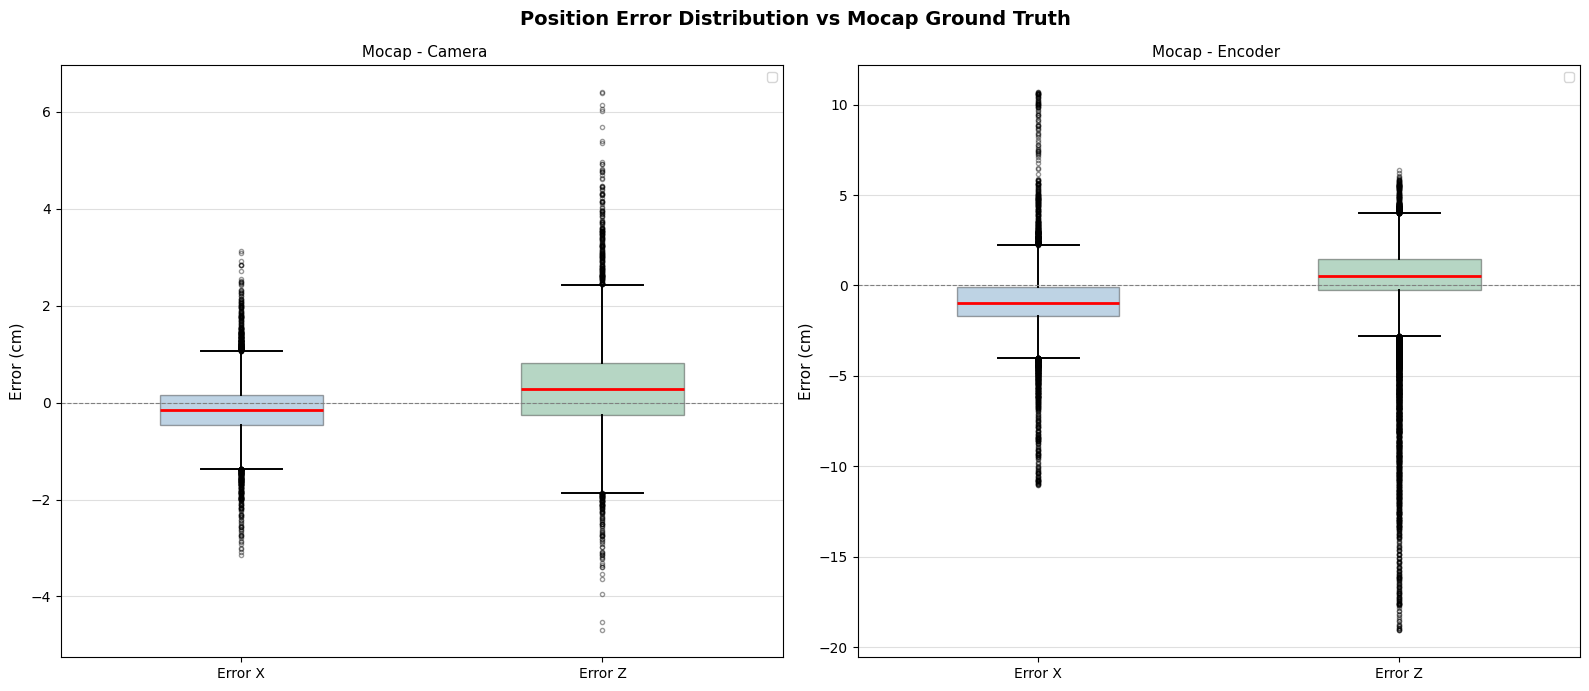

In [94]:
# Cell 38
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Position Error Distribution vs Mocap Ground Truth", fontsize=14, fontweight='bold')

# FIX (Bug 5): loop variables renamed ex/ez/e2d — no longer shadows outer err_x/err_z/err_2d
for ax, (ex, ez, title) in zip(axes, [
    (err_mc_x, err_mc_z, " Mocap - Camera"),
    (err_me_x, err_me_z, "Mocap - Encoder "),
]):
    bp = ax.boxplot(
        [ex, ez],
        labels=["Error X", "Error Z"],
        patch_artist=True, notch=False, widths=0.45,
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4),
        flierprops=dict(marker='o', markersize=3, linestyle='none', alpha=0.4),
    )
    for patch, color in zip(bp['boxes'], ['steelblue', 'seagreen', 'black']):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    # rmse = np.sqrt((e2d**2).mean())
    # ax.axhline(rmse, color='red', lw=1.2, ls=':', label=f'RMSE 2D = {rmse:.2f} cm')
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_ylabel("Error (cm)", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('plot_mocap_error_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [95]:
# # ── Compare NOARK position before and after tframe conversion ─────────────────
# noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
# df_raw = rb_dfs[noark_key].copy()
# df_tf  = tframe_dfs['noark_in_tframe'].copy()
# _nm    = tframe_dfs['_noark_marker']

# xcol_raw = f'{noark_key}_marker_m{_nm}_x'
# ycol_raw = f'{noark_key}_marker_m{_nm}_y'
# zcol_raw = f'{noark_key}_marker_m{_nm}_z'

# xcol_tf  = f'noark_m{_nm}_tf_x_m'
# zcol_tf  = f'noark_m{_nm}_tf_z_m'

# print(f"NOARK marker m{_nm} — RAW mocap frame (metres) vs TABLE frame (metres)")
# print(f"{'Frame':>6}  {'Raw X':>10}  {'Raw Z':>10}  {'TF X':>10}  {'TF Z':>10}")
# print('-' * 52)
# for i in range(min(10, len(df_raw))):
#     rx = df_raw.loc[i, xcol_raw]
#     rz = df_raw.loc[i, zcol_raw]
#     tx = df_tf.loc[i, xcol_tf]
#     tz = df_tf.loc[i, zcol_tf]
#     print(f"{i:>6}  {rx:>10.4f}  {rz:>10.4f}  {tx:>10.4f}  {tz:>10.4f}")

# print(f"\nSummary statistics:")
# print(f"{'':12}  {'Raw X':>10}  {'Raw Z':>10}  {'TF X':>10}  {'TF Z':>10}")
# print(f"{'mean':12}  {df_raw[xcol_raw].mean():>10.4f}  {df_raw[zcol_raw].mean():>10.4f}  {df_tf[xcol_tf].mean():>10.4f}  {df_tf[zcol_tf].mean():>10.4f}")
# print(f"{'min':12}  {df_raw[xcol_raw].min():>10.4f}  {df_raw[zcol_raw].min():>10.4f}  {df_tf[xcol_tf].min():>10.4f}  {df_tf[zcol_tf].min():>10.4f}")
# print(f"{'max':12}  {df_raw[xcol_raw].max():>10.4f}  {df_raw[zcol_raw].max():>10.4f}  {df_tf[xcol_tf].max():>10.4f}  {df_tf[zcol_tf].max():>10.4f}")

Sanity check for triangle inequality violation

In [96]:
# # Compare enc1/enc2 absolute values across full recording vs t=28-34s window
# print("=== Full recording ===")
# print(f"enc1 range: {enc_s['enc1'].min():.2f} → {enc_s['enc1'].max():.2f} deg")
# print(f"enc2 range: {enc_s['enc2'].min():.2f} → {enc_s['enc2'].max():.2f} deg")

# mask_drop = (enc_s['t_sec'] >= 28.0) & (enc_s['t_sec'] <= 34.0)
# print("\n=== Dropout window t=28-34s ===")
# print(f"enc1 range: {enc_s.loc[mask_drop, 'enc1'].min():.2f} → {enc_s.loc[mask_drop, 'enc1'].max():.2f} deg")
# print(f"enc2 range: {enc_s.loc[mask_drop, 'enc2'].min():.2f} → {enc_s.loc[mask_drop, 'enc2'].max():.2f} deg")

# # Also check cable lengths in that window
# mask_drop_enc = (enc_s['t_sec'] >= 28.0) & (enc_s['t_sec'] <= 34.0)
# enc_drop = enc_s[mask_drop_enc]
# L_L = P2_to_NOARK_init_mocap + r_ML * np.deg2rad(enc_drop['enc1'].values)
# L_R = P4_to_NOARK_init_mocap - r_MR * np.deg2rad(enc_drop['enc2'].values)

# d = np.sqrt((P4_mocap[0]-P2_mocap[0])**2 + (P4_mocap[2]-P2_mocap[2])**2)

# print(f"\nP2-P4 distance       : {d*100:.3f} cm")
# print(f"L_free_L range       : {L_L.min()*100:.3f} → {L_L.max()*100:.3f} cm")
# print(f"L_free_R range       : {L_R.min()*100:.3f} → {L_R.max()*100:.3f} cm")
# print(f"L_free_L + L_free_R  : {(L_L+L_R).min()*100:.3f} → {(L_L+L_R).max()*100:.3f} cm")
# print(f"|L_free_L - L_free_R|: {np.abs(L_L-L_R).min()*100:.3f} → {np.abs(L_L-L_R).max()*100:.3f} cm")
# print(f"Frames where |L_L-L_R| > d: {(np.abs(L_L-L_R) > d).sum()}  ← triangle inequality violation")

In [97]:
# print("=== BEFORE shift ===")
# print(f"MAE X : {np.mean(np.abs(err_x_before[mask_before])):.3f} cm")
# print(f"MAE Z : {np.mean(np.abs(err_z_before[mask_before])):.3f} cm")
# print(f"RMSE X: {np.sqrt(np.mean(err_x_before[mask_before]**2)):.3f} cm")
# print(f"RMSE Z: {np.sqrt(np.mean(err_z_before[mask_before]**2)):.3f} cm")

In [98]:
# # ── Combined plot: Z error vs pulley proximity ────────────────────────────────
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# # ── Plot 1: Z position mocap vs encoder ──────────────────────────────────────
# ax1.plot(merged['t_sec'], merged['z_mocap_cm'], 'k-',  lw=1.5, label='Mocap (GT) Z')
# ax1.plot(merged['t_sec'], merged['z_enc_cm'],   color='orange', ls='--', lw=1.2, label='Encoder Z')
# ax1.set_ylabel('Z position (cm)')
# ax1.set_title('Z position — Mocap vs Encoder')
# ax1.legend(loc='upper right'); ax1.grid(True, alpha=0.4)

# # ── Plot 2: Z error ───────────────────────────────────────────────────────────
# ax2.plot(merged['t_sec'], merged['err_me_z_cm'], color='red', lw=1.2, label='Z error (enc - mocap)')
# ax2.axhline(0, color='black', lw=0.8, ls='--')
# ax2.set_ylabel('Z error (cm)')
# ax2.set_title('Encoder Z error')
# ax2.legend(loc='upper right'); ax2.grid(True, alpha=0.4)

# # ── Plot 3: Distance to P2 and P4 ────────────────────────────────────────────
# ax3.plot(t_sec, dist_P2, color='steelblue', lw=1.2, label='Distance to P2 (left)')
# ax3.plot(t_sec, dist_P4, color='seagreen',  lw=1.2, label='Distance to P4 (right)')
# ax3.axhline(35, color='red', ls='--', lw=1, label='35 cm threshold')

# # shade close-approach windows on all subplots
# close_windows = [
#     (6.03,  6.73,  'P2'),
#     (12.80, 13.48, 'P2'),
#     (14.17, 15.08, 'P4'),
#     (4.38,  5.36,  'P4'),
#     (2.72,  3.83,  'P2'),
# ]
# for t_s, t_e, label in close_windows:
#     color = 'steelblue' if label == 'P2' else 'seagreen'
#     for ax in [ax1, ax2, ax3]:
#         ax.axvspan(t_s, t_e, alpha=0.15, color=color)

# ax3.set_ylabel('Distance (cm)')
# ax3.set_xlabel('Time (s)')
# ax3.set_title('NOARK distance to P2 and P4')
# ax3.legend(loc='upper right'); ax3.grid(True, alpha=0.4)

# plt.tight_layout()
# plt.savefig('z_error_vs_pulley_proximity.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ── Print correlation ─────────────────────────────────────────────────────────
# print("Close-approach windows vs max Z error:")
# print(f"{'Window':>20}  {'Pulley':>6}  {'Max |Z error| in window':>25}")
# for t_s, t_e, label in close_windows:
#     w = (merged['t_sec'] >= t_s) & (merged['t_sec'] <= t_e)
#     max_err = merged.loc[w, 'err_me_z_cm'].abs().max()
#     print(f"  t={t_s:.2f}–{t_e:.2f}s  {label:>6}  {max_err:>10.3f} cm")

In [99]:
# print("cam_df columns:", cam_df.columns.tolist())
# print("cam x range:", cam_df['x_cam'].min(), "→", cam_df['x_cam'].max())
# print("cam z range:", cam_df['z_cam'].min(), "→", cam_df['z_cam'].max())
# print("enc x range:", enc_s['x_enc'].min(), "→", enc_s['x_enc'].max())
# print("enc z range:", enc_s['z_enc'].min(), "→", enc_s['z_enc'].max())